In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

In [4]:
EBC = pd.read_csv('equal_beta_portfolio_return.csv', index_col=0)
EBC.columns = ["EBC"]
EBC.index = pd.to_datetime(EBC.index)
EBC

,EBC
date,
1967-01-01,0.105809
1967-02-01,0.007303
1967-03-01,0.043577
1967-04-01,0.032736
1967-05-01,-0.027935
...,...
2024-08-01,0.030202
2024-09-01,0.016253
2024-10-01,-0.016896


In [5]:
ff_df = pd.read_csv("F-F_Research_Data_5_Factors_2x3.csv", index_col=0, skiprows=3)

# Keep only rows with YYYYMM format
ff_df = ff_df[ff_df.index.astype(str).str.match(r"^\d{6}$")]

# Convert index to period-end timestamps (e.g., '202401' -> '2024-01-31')
ff_df.index = pd.to_datetime(ff_df.index.astype(str), format="%Y%m").to_period("M").to_timestamp("M")

# Convert all factor values to numeric and scale to decimal
ff_df = ff_df.apply(pd.to_numeric, errors='coerce') / 100

ff_df.index = pd.to_datetime(ff_df.index).to_period('M').start_time

ff_df = ff_df.loc[EBC.index]

ff_df = ff_df["RF"]
ff_df

date
1967-01-01    0.0043
1967-02-01    0.0036
1967-03-01    0.0039
1967-04-01    0.0032
1967-05-01    0.0033
               ...  
2024-08-01    0.0048
2024-09-01    0.0040
2024-10-01    0.0039
2024-11-01    0.0040
2024-12-01    0.0037
Name: RF, Length: 696, dtype: float64

In [6]:
Cap_EBC = pd.read_csv('spread.csv', index_col=0)
Cap_EBC.index = pd.to_datetime(Cap_EBC.index)
Cap_EBC

,Spread Return
date,
1967-01-01,-0.022394
1967-02-01,0.002736
1967-03-01,0.000430
1967-04-01,0.014722
1967-05-01,-0.016680
...,...
2024-08-01,-0.002086
2024-09-01,0.009603
2024-10-01,0.012110


In [7]:
sp_500 = pd.read_csv('sp500_returns_with_tickers.csv', index_col=0)
sp_500.index = pd.to_datetime(sp_500.index).to_period('M').start_time
sp500 = sp_500.loc[Cap_EBC.index]
sp500

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1967-01-01,0.140523,0.145374,0.146104,NaN,0.105364,NaN,NaN,NaN,-0.045045,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-02-01,-0.036103,-0.015385,-0.019830,NaN,0.029463,NaN,NaN,NaN,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-03-01,0.156627,0.020313,0.102339,NaN,0.112245,NaN,NaN,NaN,-0.035849,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-04-01,0.052083,0.007752,0.018568,NaN,0.039755,NaN,NaN,NaN,0.079208,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-05-01,-0.018812,-0.023077,-0.072917,NaN,-0.064706,NaN,NaN,NaN,-0.108257,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,NaN,NaN,NaN,NaN,NaN,0.013195,-0.001100,NaN,NaN,-0.071535,...,NaN,0.013319,0.042292,-0.310823,0.321675,NaN,0.005460,NaN,0.122718,-0.077391
2024-09-01,NaN,NaN,NaN,NaN,NaN,0.206030,0.031548,NaN,NaN,0.038948,...,NaN,0.062707,-0.016385,0.019284,0.010950,NaN,0.015013,NaN,-0.002580,0.221942
2024-10-01,NaN,NaN,NaN,NaN,NaN,-0.012676,-0.055659,NaN,NaN,0.008538,...,NaN,-0.015826,0.025228,-0.046589,0.014313,NaN,0.041981,NaN,0.042466,-0.045025


In [8]:
rf = ff_df.reindex(EBC.index)

EBC = EBC.subtract(rf, axis=0)
Cap_EBC = Cap_EBC.subtract(rf, axis=0)
sp500 = sp500.subtract(rf, axis=0)
EBC


,EBC
date,
1967-01-01,0.101509
1967-02-01,0.003703
1967-03-01,0.039677
1967-04-01,0.029536
1967-05-01,-0.031235
...,...
2024-08-01,0.025402
2024-09-01,0.012253
2024-10-01,-0.020796


<Axes: xlabel='date'>

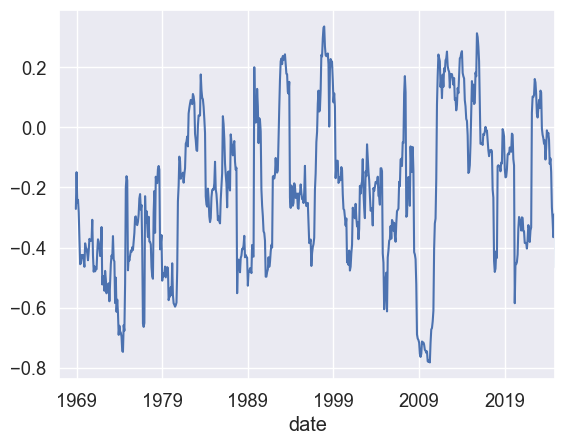

In [36]:
corr = EBC["EBC"].rolling(window=24).corr(Cap_EBC["Spread Return"])
corr.plot()

<Axes: xlabel='date'>

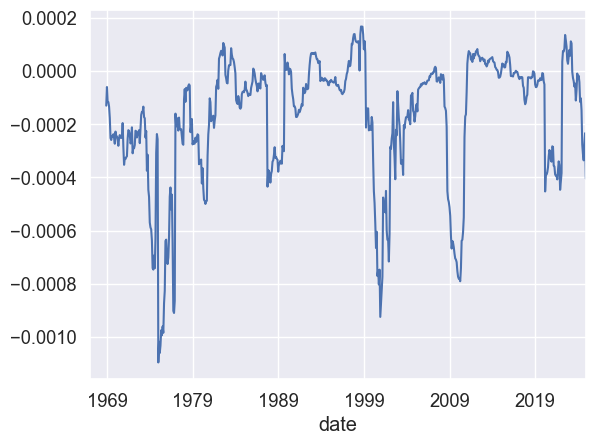

In [37]:
cov = EBC["EBC"].rolling(window=24).cov(Cap_EBC["Spread Return"])
cov.plot()

In [9]:
def compute_betas(sp500, factor_returns, ROLLING_WINDOW=36, MIN_OBS=10):
    """2 pass multi factor Fama-MacBeth"""

    asset_cols = sp500.columns
    combined = sp500.join(factor_returns, how="inner")

    # Prepare betas containers as float from the start
    betas_dict = {
        f: pd.DataFrame(index=pd.Index([], name="date"), columns=asset_cols, dtype=float)
        for f in factor_returns.columns
    }
    beta_dates = []

    # ---------- First pass: rolling time-series ----------
    for end_date in tqdm(combined.index[ROLLING_WINDOW-1:-1], desc="Time-series betas"):
        pos = combined.index.get_loc(end_date)
        next_date = combined.index[pos + 1]

        start_idx = pos - (ROLLING_WINDOW - 1)
        window_dates = combined.index[start_idx: start_idx + ROLLING_WINDOW]

        # Build window, drop any rows where either y or X has NaN
        x_win = factor_returns.loc[window_dates]
        for asset in asset_cols:
            y_win = sp500.loc[window_dates, asset]
            data = pd.concat([y_win, x_win], axis=1).dropna()
            if len(data) < MIN_OBS:
                for f in factor_returns.columns:
                    betas_dict[f].loc[next_date, asset] = np.nan
                continue

            Y = pd.to_numeric(data[asset], errors="coerce").astype(float)
            X = sm.add_constant(
                data[factor_returns.columns].apply(pd.to_numeric, errors="coerce").astype(float),
                has_constant="add"
            )

            # Guard against singular matrix if too few distinct X rows
            if X.shape[0] <= X.shape[1] or np.linalg.matrix_rank(X) < X.shape[1]:
                for f in factor_returns.columns:
                    betas_dict[f].loc[next_date, asset] = np.nan
                continue

            res = sm.OLS(Y, X).fit()

            for f in factor_returns.columns:
                betas_dict[f].loc[next_date, asset] = res.params.get(f, np.nan)

        beta_dates.append(next_date)

    return betas_dict

In [10]:
betas_EBC = compute_betas(sp500, EBC, 36, 10)
betas_Cap_EBC = compute_betas(sp500, Cap_EBC, 36, 10)

Time-series betas: 100%|██████████| 660/660 [10:41<00:00,  1.03it/s]


In [52]:
Betas_EBC = betas_EBC["EBC"]
# Betas_EBC = Betas_EBC[:400]
dic = {"EBC": Betas_EBC}
dic

{'EBC':                  ACF       ABK       AMT  JAVA        AN      ORCL      MSFT  \
 date                                                                           
 1970-01-01  1.333162  1.499542  0.510353   NaN  1.165416       NaN       NaN   
 1970-02-01  1.327381  1.527215  0.402780   NaN  1.034648       NaN       NaN   
 1970-03-01  1.290869  1.515709  0.349719   NaN  0.991152       NaN       NaN   
 1970-04-01  1.226908  1.561163  0.290040   NaN  0.949461       NaN       NaN   
 1970-05-01  1.165779  1.588972  0.309336   NaN  0.936422       NaN       NaN   
 ...              ...       ...       ...   ...       ...       ...       ...   
 2024-08-01       NaN       NaN       NaN   NaN       NaN  1.179202  0.779066   
 2024-09-01       NaN       NaN       NaN   NaN       NaN  1.173630  0.763392   
 2024-10-01       NaN       NaN       NaN   NaN       NaN  1.198837  0.740915   
 2024-11-01       NaN       NaN       NaN   NaN       NaN  1.182902  0.686763   
 2024-12-01       NaN

In [53]:
Betas_Cap_EBC = betas_Cap_EBC["Spread Return"]
# Betas_Cap_EBC = Betas_Cap_EBC[:400]
dic2 = {"Spread Return": Betas_Cap_EBC}

In [72]:
# Two-way sort -> equal-weight portfolios -> TS regressions -> Fama-MacBeth
# Assumes:
# - sp500 : DataFrame of asset returns (index dates), columns = tickers
# - betas_EBC: dict returned by compute_betas, e.g. {'EBC': DataFrame(dates x tickers)}
# - betas_Cap_EBC: dict returned by compute_betas for the second factor (spread)
# - factor series (EBC, Cap_EBC) are available as DataFrames EBC and Cap_EBC used earlier

# PARAMETERS
n_q1 = 3
n_q2 = 3
min_assets_per_cell = 3  #require at least this many assets to compute a portfolio return

# pick factor names (from your betas dicts)
f1_name = list(betas_EBC.keys())[0]
f2_name = list(betas_Cap_EBC.keys())[0]

# intersect dates where both beta matrices have rows and sp500 has returns
dates1 = dic[f1_name].index
dates2 = dic2[f2_name].index
dates_common = dates1.intersection(dates2).intersection(sp500.index)

# container for portfolio returns (equal-weighted)
port_ret_rows = []

print(f"Using factor names: f1={f1_name}, f2={f2_name}")
print(f"Number of rebalance dates: {len(dates_common)}")

for date in tqdm(sorted(dates_common), desc="forming portfolios"):
    try:
        beta1 = dic[f1_name].loc[date]   # Series indexed by asset
        beta2 = dic2[f2_name].loc[date]
    except KeyError:
        # skip if a factor missing for this date
        continue

    # returns at the same date (matching compute_betas design)
    if date not in sp500.index:
        continue
    ret_t = sp500.loc[date]

    df = pd.DataFrame({
        'beta1': beta1,
        'beta2': beta2,
        'ret': ret_t
    })

    df = df.dropna(subset=['beta1', 'beta2', 'ret'])
    if df.shape[0] == 0:
        continue

    # create quantiles robustly: try qcut, but fallback to rank-based if qcut fails
    def assign_q(series, nq):
        try:
            q = pd.qcut(series, nq, labels=False) + 1
        except Exception:
            # fallback: rank / quantiles
            ranks = series.rank(method='first')
            q = pd.cut(ranks, bins=nq, labels=False) + 1
        return nq + 1 - q

    df['q1'] = assign_q(df['beta1'], n_q1)
    print(df["q1"])
    df['q2'] = assign_q(df['beta2'], n_q2)

    if 'quantile_map' not in locals():
        quantile_map = []
    for i in range(1, n_q1 + 1):
        for j in range(1, n_q2 + 1):
            stocks_in_cell = df.index[(df['q1'] == i) & (df['q2'] == j)].tolist()
            quantile_map.append({'date': date, 'q1': i, 'q2': j, 'stocks': stocks_in_cell})

    # compute equal-weighted return for each cell
    for i in range(1, n_q1+1):
        for j in range(1, n_q2+1):
            cell = df[(df['q1'] == i) & (df['q2'] == j)]
            if cell.shape[0] < min_assets_per_cell:
                # not enough assets -> nan (keeps panel consistent)
                ret_ew = np.nan
                n_assets = cell.shape[0]
            else:
                ret_ew = cell['ret'].mean()
                n_assets = cell.shape[0]

            port_ret_rows.append({
                'date': date,
                'q1': i,
                'q2': j,
                'ret_ew': ret_ew,
                'n_assets': n_assets
            })

# build DataFrame of portfolio returns
portrets = pd.DataFrame(port_ret_rows)

if 'quantile_map' in locals():
    quantile_map_df = pd.DataFrame(quantile_map)
    quantile_map_df.set_index(['date', 'q1', 'q2'], inplace=True)
    print("\nQuantile membership table created:")
    print(quantile_map_df.head())
else:
    print("No quantile_map found — make sure code inside loop ran correctly.")
portrets['date'] = pd.to_datetime(portrets['date'])
portrets = portrets.set_index(['date', 'q1', 'q2']).sort_index()

# Pivot to wide: columns are portfolio labels like "q1_q2" (useful for regressions)
portrets_wide = portrets['ret_ew'].unstack(level=[1,2])  # columns MultiIndex (q1,q2)
# flatten cols to strings
portrets_wide.columns = [f"Q{c[0]}_Q{c[1]}" for c in portrets_wide.columns]
portrets_wide = portrets_wide.sort_index(axis=1)

print("\nPortfolio panel shape (dates x portfolios):", portrets_wide.shape)
print("Example columns:", portrets_wide.columns[:8].tolist())
print(portrets_wide.head(100))

# ============================
# 1) Time-series regressions per portfolio (TS betas, alphas)
# ============================
# prepare factor returns series aligned to the portfolio index
# factor DataFrames EBC and Cap_EBC already exist in your workspace; ensure they align
factors = pd.concat([EBC, Cap_EBC], axis=1).dropna()
factors = factors.loc[portrets_wide.index.intersection(factors.index)]
portrets_wide = portrets_wide.loc[portrets_wide.index.intersection(factors.index)]

# ensure same date order
factors = factors.loc[portrets_wide.index]

ts_res = {}   # store regression results per portfolio
for port in portrets_wide.columns:
    y = portrets_wide[port].dropna()
    if len(y) < 12:
        # skip portfolios with too few observations
        ts_res[port] = None
        continue
    X = factors.loc[y.index]
    Xc = sm.add_constant(X, has_constant='add')
    try:
        model = sm.OLS(y, Xc).fit()
    except Exception as e:
        ts_res[port] = None
        continue

    ts_res[port] = {
        'alpha': model.params['const'],
        'alpha_t': model.tvalues['const'],
        'betaEBC': model.params.get(f1_name, np.nan),
        'betaCap_EBC': model.params.get(f2_name, np.nan),
        'betaEBC_t': model.tvalues.get(f1_name, np.nan),
        'betaCap_EBC_t': model.tvalues.get(f2_name, np.nan),
        'rsq': model.rsquared,
        'nobs': int(model.nobs)
    }

# TS results DataFrame
ts_summary = pd.DataFrame.from_dict(ts_res, orient='index')
print("\nTime-series regressions summary:")
print(ts_summary.dropna().head(25))

# ============================
# 2) Fama-MacBeth across portfolios
#    - Step A: get portfolio betas (we use the TS full-sample betas estimated above)
#    - Step B: for each date t, run cross-sectional regression: R_pt = gamma0_t + gamma1_t * beta1_p + gamma2_t * beta2_p + e_pt
#    - Step C: average gamma_t across time, compute t-stats
# ============================

# collect portfolio-level betas (from ts_summary)
beta_table = ts_summary[['betaEBC', 'betaCap_EBC']].copy()
beta_table = beta_table.dropna()
print("aaaaa")
print(beta_table.head(25))

# Align portfolio returns to the set of portfolios for which we have betas
valid_ports = beta_table.index.tolist()
R_panel = portrets_wide[valid_ports].copy()

# make sure index order consistent with factors
R_panel = R_panel.loc[factors.index.intersection(R_panel.index)]
print("aaaaa")
print(R_panel)
factors = factors.loc[R_panel.index]
print("aaaaa")
print(factors)

# At each date, run the cross-section
gamma_rows = []
cs_nobs = 0
for date, row in R_panel.iterrows():
    R_t = row.dropna()
    if R_t.shape[0] < 3:
        gamma_rows.append({'date': date, 'alpha': np.nan, 'lambdaEBC': np.nan, 'lambda_Cap_EBC': np.nan})
        continue

    # the betas are time-invariant here (portfolio-level)
    beta_mat = beta_table.loc[R_t.index]  # rows = portfolios in cross-section
    X_cs = sm.add_constant(beta_mat)
    try:
        res_cs = sm.OLS(R_t.values, X_cs.values).fit()
        params = res_cs.params
        gamma_rows.append({'date': date, 'alpha': params[0], 'lambdaEBC': params[1], 'lambda_Cap_EBC': params[2]})
        cs_nobs += 1
    except Exception:
        gamma_rows.append({'date': date, 'alpha': np.nan, 'lambdaEBC': np.nan, 'lambda_Cap_EBC': np.nan})

gammas = pd.DataFrame(gamma_rows).set_index('date')
print("aaaaa")
print(gammas)

# drop missing
gammas = gammas.dropna()

# FM estimates: mean of gamma_t and t-stat = mean(gamma)/ (std(gamma)/sqrt(T))
T_eff = gammas.shape[0]
fm_mean = gammas.mean()
fm_se = gammas.std(ddof=1) / np.sqrt(T_eff)
fm_tstats = fm_mean / fm_se

fm_table = pd.DataFrame({
    'lambda_mean': fm_mean,
    'lambda_se': fm_se,
    'lambda_fm_tstat': fm_tstats
})
print("\nFama-MacBeth results (factor premia):")
print(fm_table)

# ============================
# 3) Pricing errors (alphas) under FM prices
#    For each portfolio p: alpha_FM_p = mean(R_p) - (beta_p1 * gamma1_mean + beta_p2 * gamma2_mean + gamma0_mean)
#    Also present TS regression alpha for comparison
# ============================
gamma0_bar = fm_table.loc['alpha', 'lambda_mean']
gamma1_bar = fm_table.loc['lambdaEBC', 'lambda_mean']
gamma2_bar = fm_table.loc['lambda_Cap_EBC', 'lambda_mean']

portfolio_mean_returns = R_panel.mean()
pricing_errors = []
for p in valid_ports:
    mean_r = portfolio_mean_returns[p]
    b1 = beta_table.loc[p, 'betaEBC']
    b2 = beta_table.loc[p, 'betaCap_EBC']
    alpha_fm = mean_r - (gamma0_bar + gamma1_bar * b1 + gamma2_bar * b2)
    ts_alpha = ts_summary.loc[p, 'alpha'] if p in ts_summary.index else np.nan
    pricing_errors.append({
        'portfolio': p,
        'mean_return': mean_r,
        'betaEBC': b1,
        'betaCap_EBC': b2,
        'alpha_ts': ts_alpha,
        'alpha_fm': alpha_fm
    })

pricing_df = pd.DataFrame(pricing_errors).set_index('portfolio').sort_index()
print("\nPricing errors and betas for portfolios:")
print(pricing_df.head(25))

# ============================
# Niceties: show heatmaps / tables
# ============================
# reshape pricing_df into q1/q2 grid for alpha_fm and mean_return
grid_mean = pricing_df['mean_return'].copy()
grid_alpha = pricing_df['alpha_fm'].copy()

# helper to turn 'Q{a}_Q{b}' -> (a,b)
def split_label(lbl):
    parts = lbl.replace('Q','').split('_')
    return int(parts[0]), int(parts[1])

# build DataFrames
mean_grid = pd.DataFrame(np.nan, index=range(1, n_q1+1), columns=range(1, n_q2+1))
alpha_grid = mean_grid.copy()
for p in pricing_df.index:
    a,b = split_label(p)
    mean_grid.loc[a,b] = pricing_df.loc[p, 'mean_return']
    alpha_grid.loc[a,b] = pricing_df.loc[p, 'alpha_fm']

print("\nMean returns grid (rows = q1, cols = q2):")
print(mean_grid)
print("\nFM pricing error grid (alpha):")
print(alpha_grid)

# Save outputs for inspection if desired
# portrets_wide.to_csv('portfolios_returns_ew.csv')
# ts_summary.to_csv('portfolio_ts_summary.csv')
# fm_table.to_csv('fama_macbeth_results.csv')
# pricing_df.to_csv('portfolio_pricing_errors.csv')



Using factor names: f1=EBC, f2=Spread Return
Number of rebalance dates: 660


forming portfolios:   4%|▎         | 24/660 [00:00<00:02, 233.37it/s]

ACF     1
AMT     3
AN      2
AYE     3
HON     1
       ..
IBP     3
CLX     2
SFF     3
DFC     3
CFIP    1
Name: q1, Length: 492, dtype: int64
ACF     1
AMT     3
AN      2
AYE     3
HON     2
       ..
IBP     3
CLX     1
SFF     3
DFC     3
CFIP    2
Name: q1, Length: 492, dtype: int64
ACF     1
AMT     3
AN      2
AYE     3
HON     2
       ..
IBP     3
CLX     1
SFF     3
DFC     2
CFIP    2
Name: q1, Length: 490, dtype: int64
ACF     1
AMT     3
AN      2
AYE     3
HON     2
       ..
IBP     3
CLX     1
SFF     3
DFC     2
CFIP    2
Name: q1, Length: 478, dtype: int64
ACF     2
AMT     3
AN      2
AYE     3
HON     2
       ..
IBP     3
CLX     1
SFF     3
DFC     1
CFIP    2
Name: q1, Length: 479, dtype: int64
ACF     1
AMT     3
AN      3
AYE     3
HON     2
       ..
CLX     1
SFF     3
DFC     1
UNP     2
CFIP    2
Name: q1, Length: 477, dtype: int64
ACF     2
AMT     3
AN      2
AYE     3
HON     2
       ..
CLX     1
SFF     3
DFC     1
UNP     1
CFIP    2
Name: q1, Leng

forming portfolios:   8%|▊         | 50/660 [00:00<00:02, 245.73it/s]

ACF      2
AMT      1
AN       2
AYE      3
HON      2
        ..
GNO      1
NXG      3
BNI      3
LLY      3
OMC.1    3
Name: q1, Length: 486, dtype: int64
ACF      2
AMT      1
AN       2
AYE      3
HON      3
        ..
GNO      1
NXG      3
BNI      3
LLY      3
OMC.1    3
Name: q1, Length: 485, dtype: int64
ACF      2
AMT      1
AN       2
AYE      3
HON      3
        ..
CMR      2
OMC.1    3
MML      3
AHM      1
HT       3
Name: q1, Length: 494, dtype: int64
ACF      2
AMT      1
AN       2
AYE      3
HON      2
        ..
OMC.1    3
MML      3
AHM      1
HT       3
GHB      2
Name: q1, Length: 494, dtype: int64
ACF      2
AMT      1
AN       2
AYE      3
HON      3
        ..
OMC.1    3
MML      3
AHM      1
HT       3
GHB      2
Name: q1, Length: 491, dtype: int64
ACF      2
AMT      1
AN       2
AYE      3
HON      2
        ..
OMC.1    3
MML      3
AHM      1
HT       3
GHB      2
Name: q1, Length: 491, dtype: int64


...

forming portfolios:  99%|█████████▉| 655/660 [00:02<00:00, 273.49it/s]

ORCL    3
MSFT    3
TROW    2
HON     2
ADM     2
       ..
AVGO    2
VRSK    3
DG.2    3
FTNT    2
CBOE    3
Name: q1, Length: 489, dtype: int64
ORCL    3
MSFT    3
TROW    2
HON     2
ADM     2
       ..
AVGO    2
VRSK    3
DG.2    3
FTNT    2
CBOE    3
Name: q1, Length: 491, dtype: int64
ORCL    3
MSFT    3
TROW    2
HON     2
ADM     2
       ..
AVGO    2
VRSK    3
DG.2    3
FTNT    2
CBOE    3
Name: q1, Length: 491, dtype: int64
ORCL    3
MSFT    3
TROW    2
HON     2
ADM     2
       ..
AVGO    2
VRSK    3
DG.2    3
FTNT    2
CBOE    3
Name: q1, Length: 488, dtype: int64
ORCL    3
MSFT    3
TROW    2
HON     2
ADM     2
       ..
VRSK    3
DG.2    3
FTNT    2
CBOE    3
TSLA    3
Name: q1, Length: 490, dtype: int64
ORCL    3
MSFT    3
TROW    2
HON     2
ADM     2
       ..
VRSK    3
DG.2    3
FTNT    2
CBOE    3
TSLA    3
Name: q1, Length: 492, dtype: int64
ORCL    3
MSFT    3
TROW    2
HON     2
ADM     2
       ..
VRSK    3
DG.2    3
FTNT    2
CBOE    3
TSLA    3
Name: q1, Leng

forming portfolios: 100%|██████████| 660/660 [00:02<00:00, 270.16it/s]


Quantile membership table created:
                                                             stocks
date       q1 q2                                                   
1970-01-01 1  1   [C, FT, HW, M, COP, RCC, SOC, MSI, MAG, TXT, B...
              2   [BX, ETN, GR, OLN, TG, R, FL, DN, BOR, RLM, US...
              3   [ACF, HON, ACS, AMO, AR, A, JI, CDP, CUD, CBO,...
           2  1   [ARC, UIS, COT, DD, GM, GMBL, ITT, KRA, MZ, MA...
              2   [AN, AST, BS, CIT, CP, CGG, DEL, FST, JWL, KYR...

Portfolio panel shape (dates x portfolios): (660, 9)
Example columns: ['Q1_Q1', 'Q1_Q2', 'Q1_Q3', 'Q2_Q1', 'Q2_Q2', 'Q2_Q3', 'Q3_Q1', 'Q3_Q2']
               Q1_Q1     Q1_Q2     Q1_Q3     Q2_Q1     Q2_Q2     Q2_Q3  \
date                                                                     
1970-01-01 -0.113053 -0.097141 -0.055823 -0.091590 -0.075021 -0.024382   
1970-02-01  0.072681  0.068198  0.096474  0.049833  0.054312  0.068291   
1970-03-01 -0.014386 -0.014141 -0.016688 -0.0103

aaaaa
               alpha  lambdaEBC  lambda_Cap_EBC
date                                           
1970-01-01  0.015056  -0.066400       -0.035513
1970-02-01 -0.016868   0.072268       -0.015412
1970-03-01  0.050339  -0.043423       -0.016917
1970-04-01 -0.006234  -0.095211       -0.003340
1970-05-01 -0.019407  -0.059017        0.002968
...              ...        ...             ...
2024-08-01  0.120516  -0.091171        0.004574
2024-09-01 -0.023343   0.036354        0.001360
2024-10-01 -0.004995  -0.014481        0.000273
2024-11-01  0.061551  -0.006413        0.007934
2024-12-01 -0.021573  -0.044744        0.028384

[660 rows x 3 columns]

Fama-MacBeth results (factor premia):
                lambda_mean  lambda_se  lambda_fm_tstat
alpha              0.004059   0.002130         1.905572
lambdaEBC          0.003323   0.002742         1.211785
lambda_Cap_EBC    -0.001935   0.001001        -1.933588

Pricing errors and betas for portfolios:
           mean_return   betaEBC  betaCap

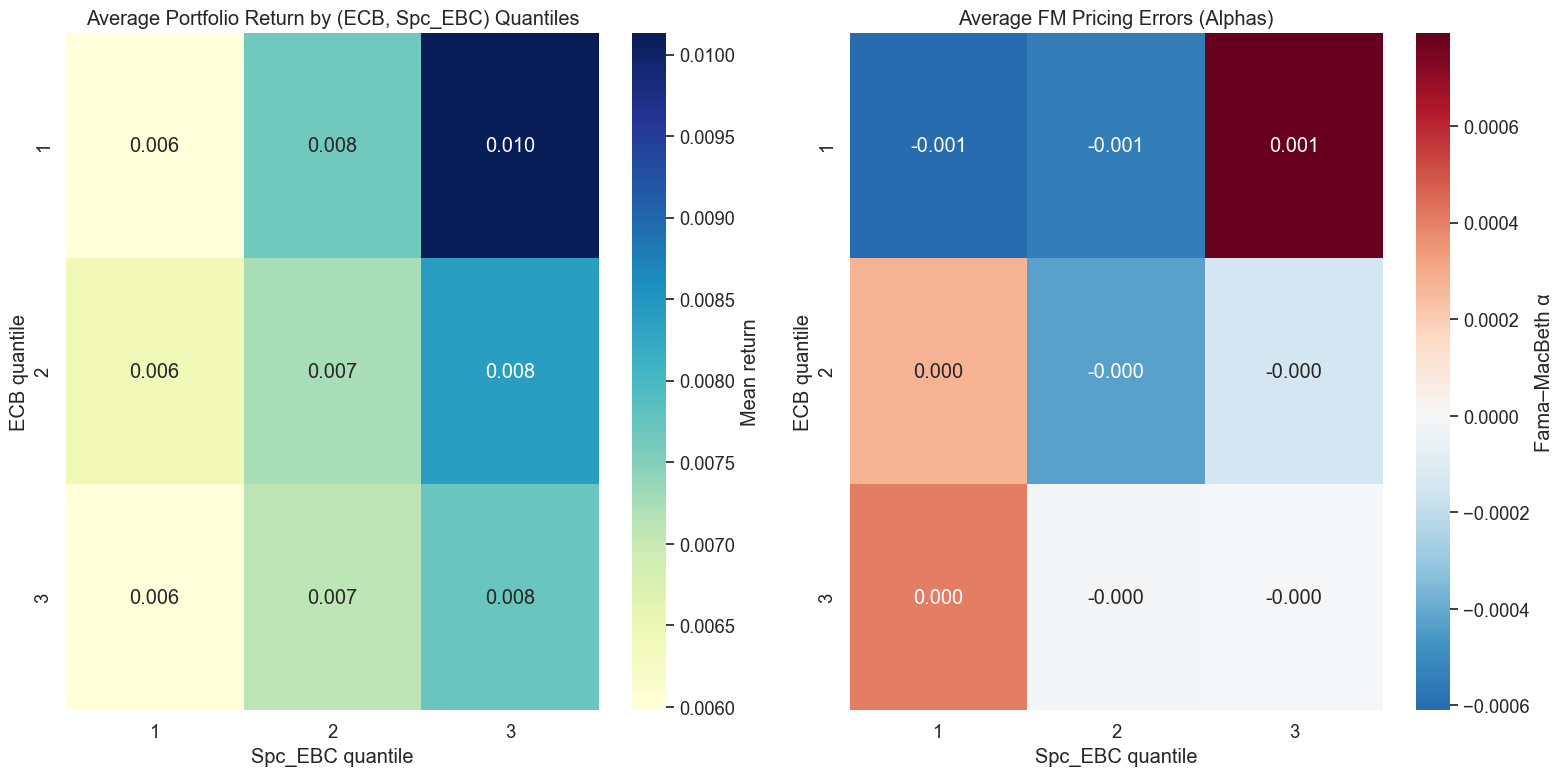

In [260]:
import seaborn as sns
import matplotlib.pyplot as plt

# set up figure aesthetics
plt.style.use("seaborn-v0_8-whitegrid")
sns.set(font_scale=1.2)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# heatmap 1: mean returns
sns.heatmap(
    mean_grid.astype(float),
    ax=axes[0],
    cmap="YlGnBu",
    annot=True,
    fmt=".3f",
    cbar_kws={'label': 'Mean return'}
)
axes[0].set_title("Average Portfolio Return by (ECB, Spc_EBC) Quantiles")
axes[0].set_xlabel("Spc_EBC quantile")
axes[0].set_ylabel("ECB quantile")

# heatmap 2: FM alpha (pricing errors)
sns.heatmap(
    alpha_grid.astype(float),
    ax=axes[1],
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".3f",
    cbar_kws={'label': 'Fama–MacBeth α'}
)
axes[1].set_title("Average FM Pricing Errors (Alphas)")
axes[1].set_xlabel("Spc_EBC quantile")
axes[1].set_ylabel("ECB quantile")

plt.tight_layout()
plt.show()


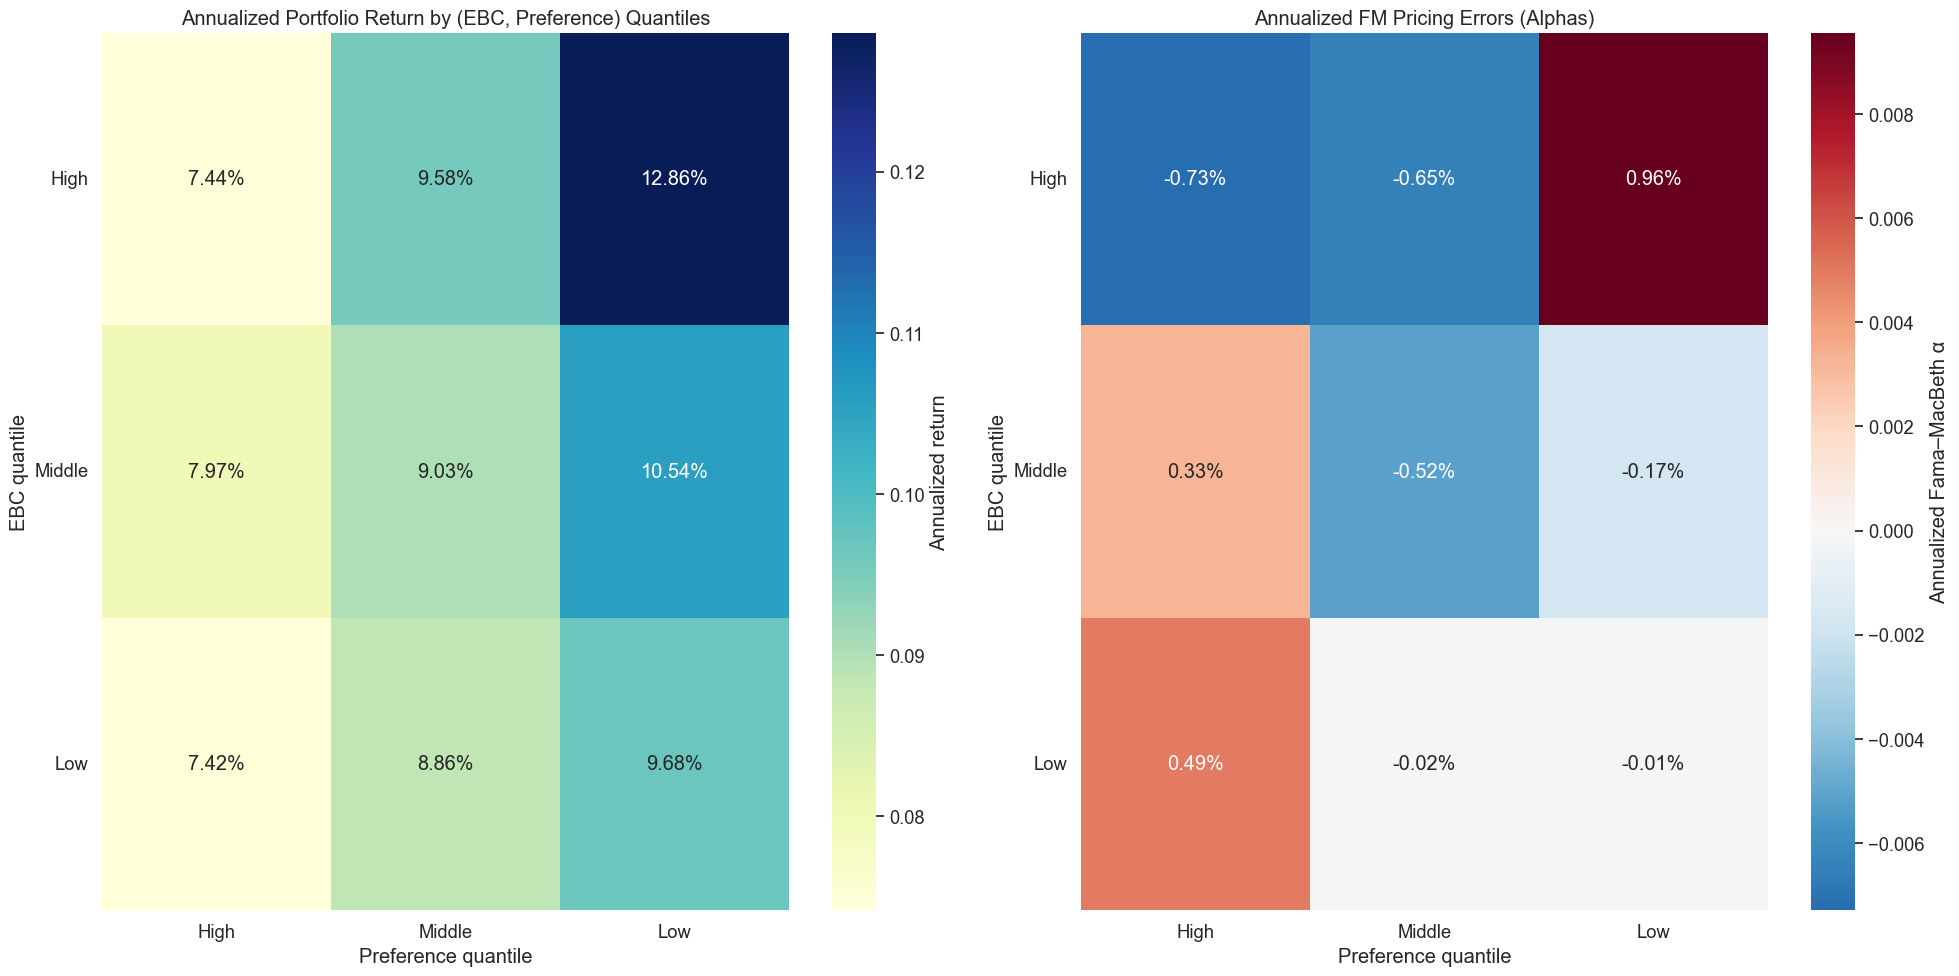

In [261]:
# annualize the grids
mean_grid_annual = (1 + mean_grid.astype(float))**12 - 1
alpha_grid_annual = (1 + alpha_grid.astype(float))**12 - 1

# plot heatmaps
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

labels = ['High', 'Middle', 'Low']

# heatmap 1: mean returns annualized
sns.heatmap(
    mean_grid_annual,
    ax=axes[0],
    cmap="YlGnBu",
    annot=True,
    fmt=".2%",
    cbar_kws={'label': 'Annualized return'}
)
axes[0].set_title("Annualized Portfolio Return by (EBC, Preference) Quantiles")
axes[0].set_xlabel("Preference quantile")
axes[0].set_ylabel("EBC quantile")
axes[0].set_xticklabels(labels)
axes[0].set_yticklabels(labels, rotation=0)


# heatmap 2: FM alpha annualized
sns.heatmap(
    alpha_grid_annual,
    ax=axes[1],
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2%",
    cbar_kws={'label': 'Annualized Fama–MacBeth α'}
)
axes[1].set_title("Annualized FM Pricing Errors (Alphas)")
axes[1].set_xlabel("Preference quantile")
axes[1].set_ylabel("EBC quantile")
axes[1].set_xticklabels(labels)
axes[1].set_yticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()


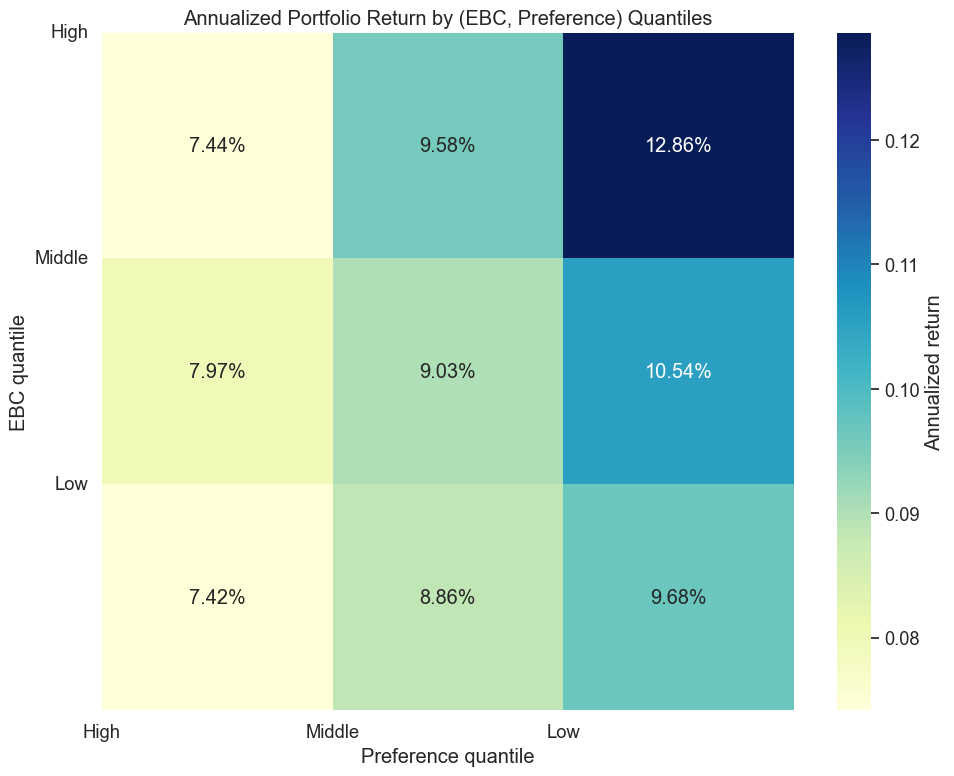

In [75]:
# annualize the mean grid
mean_grid_annual = (1 + mean_grid.astype(float))**12 - 1

# plot heatmap for annualized portfolio returns
plt.figure(figsize=(10, 8))

labels = ['High', 'Middle', 'Low']

sns.heatmap(
    mean_grid_annual,
    cmap="YlGnBu",
    annot=True,
    fmt=".2%",
    cbar_kws={'label': 'Annualized return'}
)
plt.title("Annualized Portfolio Return by (EBC, Preference) Quantiles")
plt.xlabel("Preference quantile")
plt.ylabel("EBC quantile")
plt.xticks(ticks=[0, 1, 2], labels=labels)
plt.yticks(ticks=[0, 1, 2], labels=labels, rotation=0)

plt.tight_layout()
plt.show()


In [202]:
quantile_map_df 


stocks    month
date       q1 q2                                                            
1970-01-01 1  1   [C, FT, HW, M, COP, RCC, SOC, MSI, MAG, TXT, B...  1970-01
              1   [C, FT, HW, M, COP, RCC, SOC, MSI, MAG, TXT, B...  1970-01
              1   [C, FT, HW, M, COP, RCC, SOC, MSI, MAG, TXT, B...  1970-01
              2   [BX, ETN, GR, OLN, TG, R, FL, DN, BOR, RLM, US...  1970-01
              2   [BX, ETN, GR, OLN, TG, R, FL, DN, BOR, RLM, US...  1970-01
...                                                             ...      ...
2024-12-01 3  2   [IBM, KMI, FANG, PAYC, HSY, KDP, PG, SO, FOXA,...  2024-12
              2   [IBM, KMI, FANG, PAYC, HSY, KDP, PG, SO, FOXA,...  2024-12
              3   [KO, ED, DTE, XOM, GD, LYB, HII, MPC, PCG, ABB...  2024-12
              3   [KO, ED, DTE, XOM, GD, LYB, HII, MPC, PCG, ABB...  2024-12
              3   [KO, ED, DTE, XOM, GD, LYB, HII, MPC, PCG, ABB...  2024-12

[17820 rows x 2 columns]

In [180]:
latest_date = quantile_map_df.index.get_level_values('date').max()
date = '1970-01-01'
subset = quantile_map_df.loc[(date, 1, 3), 'stocks']

#flatten lists into a single list
all_stocks = [stk for sublist in subset for stk in sublist]

#sort alphabetically (optional)
all_stocks = sorted(set([stk for sublist in subset for stk in sublist]))

for stk in all_stocks:
    print(stk)

A
ABA
ACF
ACS
ADL
AFN
AMDA
AMF
AMO
AR
BCW
BKO
BWN
CBE
CBO
CCB
CDP
CFIP
CID
CKL
COE
COX
CSCS
CTN
CUD
CW
CXT
DAL
EAL
EFU
FALB
FBD
FCF
FDB
FFI
FIN
FJC
FWLT
GAC
GAF
GD
GH
GK
GPT
GQ
GSI
GSK
GSX
GWF
GWU
HC
HES
HNS
HON
ICA
ISS
ITC
ITE
JI
JL
JOY
KSU
LCE
LLX
LPT
LST
MAN
MDP
MET
MLL.1
MMA
MMR
MQC
NUM
PAS.1
PN
PPI
PUL
RDGE
RDT
ROP
RVS
RYR
SB.1
SCI
SCM
SCO
SGIB
SLB
SPK
SR.1
SRT
SRY
SVC
SX
TF
TFB
TWX
UFL
UV
VAR
VAT
WD
WEAR
WHX
WS
WW


Mean Excess Return: 10.0663
Volatility: 0.1917
Sharpe Ratio: 0.5252
              Market
date                
1960-01-01 -0.067093
1960-02-01  0.017111
1960-03-01 -0.010623
1960-04-01 -0.013724
1960-05-01  0.037913
              Market
date                
1967-01-01  0.079115
1967-02-01  0.006439
1967-03-01  0.040107
1967-04-01  0.044258
1967-05-01 -0.047915
Market Mean Return: 12.7503
Market Volatility: 0.1523
Market Sharpe Ratio: 0.8371


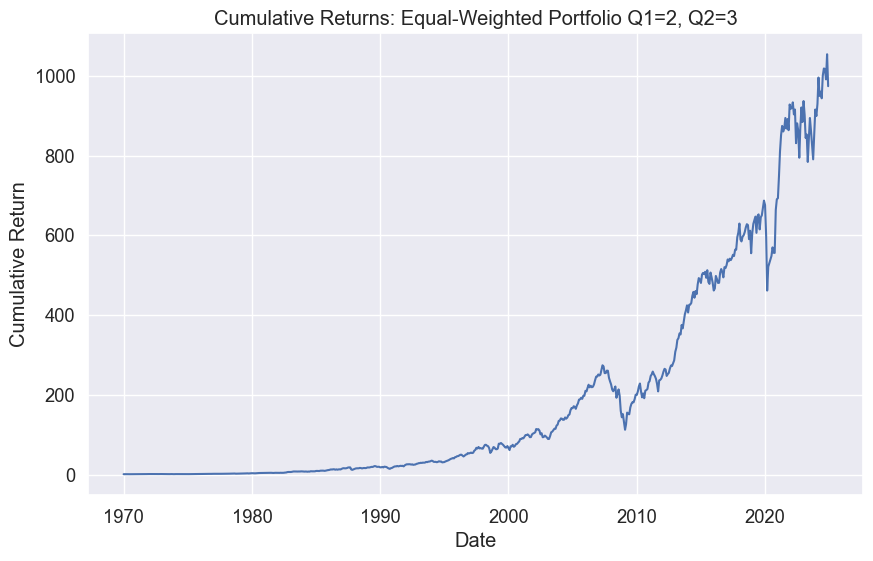

In [248]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


sp_500 = pd.read_csv('sp500_returns_with_tickers.csv', index_col=0)
sp_500.index = pd.to_datetime(sp_500.index).to_period('M').start_time  # monthly timestamps

sp_caps = pd.read_csv('sp500_market_caps.csv', index_col=0)
sp_caps.index = pd.to_datetime(sp_caps.index).to_period('M').start_time

quantile_map_df = quantile_map_df.copy()

quantile_map_df['month'] = quantile_map_df.index.get_level_values('date').to_period('M')

target_q1, target_q2 = 2, 3  #1 is high exposrue and 3 is low exposure


#compute monthly equal-weighted returns

months = sp_500.index.to_period('M').sort_values().unique()
portfolio_returns = []

for month in months:
    # select rows for this month and target quantile levels using MultiIndex
    mask = (
        (quantile_map_df['month'] == month) &
        (quantile_map_df.index.get_level_values('q1') == target_q1) &
        (quantile_map_df.index.get_level_values('q2') == target_q2)
    )
    subset = quantile_map_df.loc[mask, 'stocks']

    if subset.empty:
        portfolio_returns.append(np.nan)
        continue

    # flatten all stock lists and remove duplicates
    tickers = sorted(set([stk for sublist in subset for stk in sublist]))
    if len(tickers) == 0:
        portfolio_returns.append(np.nan)
        continue

    # select returns for these tickers in this month
    ret = sp_500.loc[sp_500.index.to_period('M') == month, tickers].mean(axis=1).values[0]
    portfolio_returns.append(ret)


portfolio_returns_series = pd.Series(portfolio_returns, index=months.to_timestamp())
excess_returns_series = portfolio_returns_series.subtract(rf, axis=0)
mean_return = excess_returns_series.mean() 
vol = excess_returns_series.std() 
sharpe_ratio = mean_return / vol
print(f"Mean Excess Return: {mean_return * 1200:.4f}")
print(f"Volatility: {vol * np.sqrt(12):.4f}")
print(f"Sharpe Ratio: {sharpe_ratio * np.sqrt(12):.4f}")

cap_weighted = pd.read_csv('sp500_cap_weighted_returns.csv', index_col=0)
cap_weighted.columns = ["Market"]
cap_weighted.index = pd.to_datetime(cap_weighted.index).to_period('M').start_time
print(cap_weighted.head())

excess_returns_cap_weighted = cap_weighted.subtract(rf, axis=0).dropna()
print(excess_returns_cap_weighted.head())

cap_weighted_mean = excess_returns_cap_weighted["Market"].mean()
vol_market = excess_returns_cap_weighted["Market"].std()
sharpe_market = cap_weighted_mean / vol_market
print(f"Market Mean Return: {cap_weighted_mean * 1200:.4f}")
print(f"Market Volatility: {vol_market * np.sqrt(12):.4f}")
print(f"Market Sharpe Ratio: {sharpe_market * np.sqrt(12):.4f}")


cumulative_returns = (1 + portfolio_returns_series).cumprod()

plt.figure(figsize=(10,6))
plt.plot(cumulative_returns.index, cumulative_returns.values)
plt.title(f'Cumulative Returns: Equal-Weighted Portfolio Q1={target_q1}, Q2={target_q2}')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load and align data ---
sp_500 = pd.read_csv('sp500_returns_with_tickers.csv', index_col=0)
sp_500.index = pd.to_datetime(sp_500.index).to_period('M').start_time  # monthly timestamps

sp_caps = pd.read_csv('sp500_market_caps.csv', index_col=0)
sp_caps.index = pd.to_datetime(sp_caps.index).to_period('M').start_time

quantile_map_df = quantile_map_df.copy()
quantile_map_df['month'] = quantile_map_df.index.get_level_values('date').to_period('M')

target_q1, target_q2 = 1, 3  # 1 = high exposure, 3 = low exposure

# --- Compute monthly cap-weighted returns ---
months = sp_500.index.to_period('M').sort_values().unique()
portfolio_returns = []

for month in months:
    # select rows for this month and target quantile levels
    mask = (
        (quantile_map_df['month'] == month) &
        (quantile_map_df.index.get_level_values('q1') == target_q1) &
        (quantile_map_df.index.get_level_values('q2') == target_q2)
    )
    subset = quantile_map_df.loc[mask, 'stocks']

    if subset.empty:
        portfolio_returns.append(np.nan)
        continue

    # flatten and remove duplicates
    tickers = sorted(set([stk for sublist in subset for stk in sublist]))
    if len(tickers) == 0:
        portfolio_returns.append(np.nan)
        continue

    # select returns and caps for these tickers in this month
    ret_row = sp_500.loc[sp_500.index.to_period('M') == month, tickers]
    caps_row = sp_caps.loc[sp_caps.index.to_period('M') == month, tickers]

    # handle missing tickers
    valid_tickers = [t for t in tickers if t in caps_row.columns and not np.isnan(caps_row[t].values[0])]
    if len(valid_tickers) == 0:
        portfolio_returns.append(np.nan)
        continue

    ret_row = ret_row[valid_tickers]
    caps_row = caps_row[valid_tickers]

    # normalize caps to sum to 1
    weights = caps_row.values[0]
    weights = weights / np.nansum(weights)
    print(weights)

    # cap-weighted return
    ret = np.nansum(ret_row.values[0] * weights)
    portfolio_returns.append(ret)

# --- Compute performance metrics ---
portfolio_returns_series = pd.Series(portfolio_returns, index=months.to_timestamp())

# --- Compare to market benchmark ---
cap_weighted = pd.read_csv('sp500_cap_weighted_returns.csv', index_col=0)
cap_weighted.index = pd.to_datetime(cap_weighted.index).to_period('M').start_time
cap_weighted.columns = ["Market"]

excess_returns_series = portfolio_returns_series.subtract(rf, axis=0)
mean_return = excess_returns_series.mean()
vol = excess_returns_series.std()
sharpe_ratio = mean_return / vol

print(f"Cap-Weighted Mean Excess Return: {mean_return * 1200:.4f}")
print(f"Cap-Weighted Volatility: {vol * np.sqrt(12):.4f}")
print(f"Cap-Weighted Sharpe Ratio: {sharpe_ratio * np.sqrt(12):.4f}")


cap_weighted_mean = cap_weighted["Market"].mean()
vol_market = cap_weighted["Market"].std()
sharpe_market = cap_weighted_mean / vol_market
print(f"Market Mean Return: {cap_weighted_mean * 1200:.4f}")
print(f"Market Volatility: {vol_market * np.sqrt(12):.4f}")
print(f"Market Sharpe Ratio: {sharpe_market * np.sqrt(12):.4f}")

# --- Plot cumulative returns ---
cumulative_returns = (1 + portfolio_returns_series).cumprod()

plt.figure(figsize=(10,6))
plt.plot(cumulative_returns.index, cumulative_returns.values, label='Cap-Weighted Portfolio')
plt.plot((1 + cap_weighted["Market"]).cumprod(), label='Market Benchmark', linestyle='--')
plt.title(f'Cumulative Returns: Cap-Weighted Portfolio Q1={target_q1}, Q2={target_q2}')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(True)
plt.legend()
plt.show()

NameError: name 'count' is not defined

DatetimeIndex(['1970-01-01', '1970-02-01', '1970-03-01', '1970-04-01',
               '1970-05-01', '1970-06-01', '1970-07-01', '1970-08-01',
               '1970-09-01', '1970-10-01',
               ...
               '2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01',
               '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', name='date', length=660, freq='MS')
DatetimeIndex(['1960-01-01', '1960-02-01', '1960-03-01', '1960-04-01',
               '1960-05-01', '1960-06-01', '1960-07-01', '1960-08-01',
               '1960-09-01', '1960-10-01',
               ...
               '2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01',
               '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', name='date', length=780, freq='MS')


,Q1_Q1,Q1_Q2,Q1_Q3,Q2_Q1,Q2_Q2,Q2_Q3,Q3_Q1,Q3_Q2,Q3_Q3,Market
date,,,,,,,,,,
2024-08-01,124.406821,432.669964,1711.614902,269.139528,542.372861,1017.725705,276.810046,689.264816,383.474613,6664.815554
2024-09-01,126.859253,452.944814,1769.939415,277.522718,555.550514,1016.540469,280.724567,697.390779,388.111896,6837.169622
2024-10-01,121.342580,453.471690,1722.643195,275.861874,555.501754,990.369056,277.719219,679.914700,380.934180,6804.441505
2024-11-01,128.051884,485.252458,1793.830107,296.049192,596.809980,1053.404604,294.933342,719.212834,396.765048,7256.737335
2024-12-01,121.429439,454.209894,1623.662405,282.546882,553.544013,973.299025,284.915370,674.470914,370.290312,7146.788429


,Q1_Q1,Q1_Q2,Q1_Q3,Q2_Q1,Q2_Q2,Q2_Q3,Q3_Q1,Q3_Q2,Q3_Q3,Market
date,,,,,,,,,,
1970-01-01,-0.107053,-0.091141,-0.049823,-0.085590,-0.069021,-0.018382,-0.059972,-0.025280,-0.023759,-0.071530
1970-02-01,0.078881,0.074398,0.102674,0.056033,0.060512,0.074491,0.041543,0.065711,0.050796,0.063582
1970-03-01,-0.008686,-0.008441,-0.010988,-0.004673,0.018136,0.010601,-0.015312,0.008882,0.053868,0.005553
1970-04-01,-0.133136,-0.153467,-0.127585,-0.110839,-0.086246,-0.096504,-0.094138,-0.079272,-0.089431,-0.085739
1970-05-01,-0.075390,-0.079622,-0.113163,-0.097109,-0.073349,-0.085165,-0.074148,-0.058044,-0.058077,-0.049981
...,...,...,...,...,...,...,...,...,...,...
2024-08-01,-0.002907,0.002744,0.002125,0.021911,0.036612,0.018236,0.056350,0.035994,0.049785,0.028116
2024-09-01,0.019556,0.046752,0.034056,0.031033,0.024252,-0.001163,0.014091,0.011772,0.012061,0.025856
2024-10-01,-0.043146,0.001161,-0.026707,-0.005963,-0.000088,-0.025720,-0.010668,-0.025023,-0.018446,-0.004786


0.11729961688438903
0.24078661797337986
aaaaa
0.1353249778000774
0.21613752031901043
aaaaa
0.16511534098955089
0.24455783855215932
aaaaa
0.12043703755030952
0.18547286685343833
aaaaa
0.1302449195132383
0.17175163069530672
aaaaa
0.14415942169996393
0.19141131514753415
aaaaa
0.11524475958967957
0.15439846964625722
aaaaa
0.128681953938853
0.13889698776105117
aaaaa
0.12514352429164077
0.1788439382453396
aaaaa


,Q1,Q2,Q3
Q1,0.487152,0.626106,0.675159
Q2,0.649351,0.758333,0.753139
Q3,0.746411,0.926456,0.699736


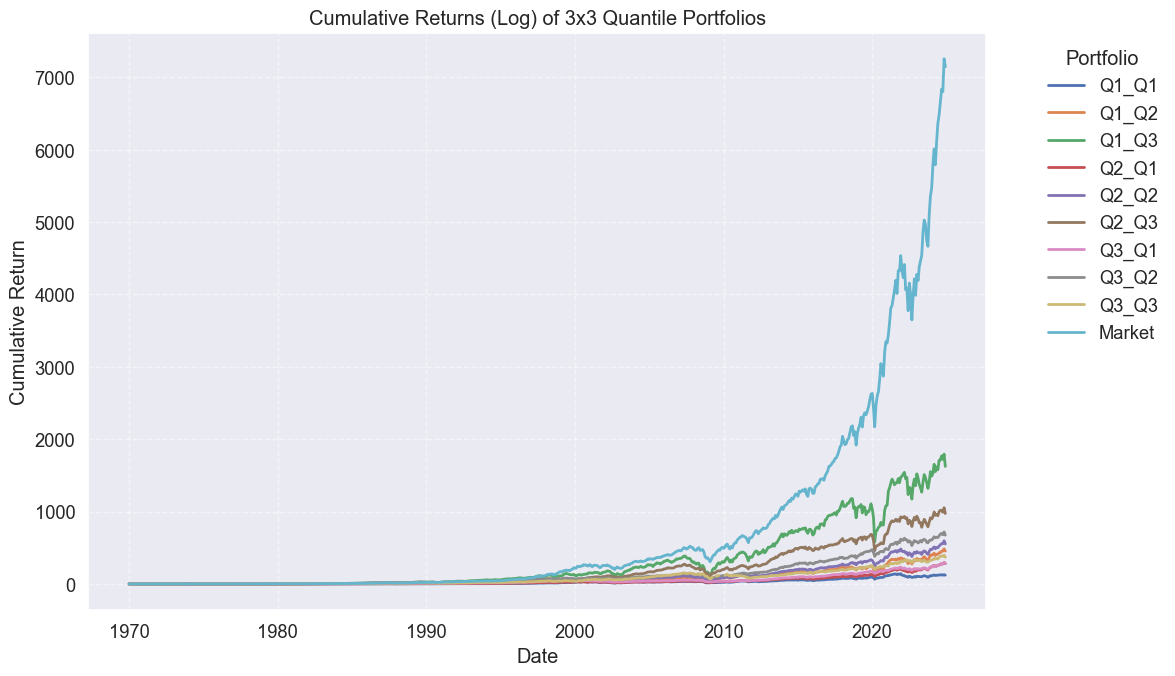

In [282]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

###Equal weighted portfolios

sp_500 = pd.read_csv('sp500_returns_with_tickers.csv', index_col=0)
sp_500.index = pd.to_datetime(sp_500.index).to_period('M').start_time  # monthly timestamps

quantile_map_df = quantile_map_df.copy()
quantile_map_df['month'] = quantile_map_df.index.get_level_values('date').to_period('M')


n_q1, n_q2 = 3, 3  # 3x3 grid
months = quantile_map_df.index.get_level_values('date').to_period('M').sort_values().unique()

# Container for all portfolio returns
all_portfolio_returns = pd.DataFrame(index=months.to_timestamp())

#iterate over quantile portfolios and calculate log returns
for q1 in range(1, n_q1 + 1):
    for q2 in range(1, n_q2 + 1):
        portfolio_returns = []
        for month in months:
            # select rows for this month & quantile cell
            mask = (
                (quantile_map_df['month'] == month) &
                (quantile_map_df.index.get_level_values('q1') == q1) &
                (quantile_map_df.index.get_level_values('q2') == q2)
            )
            subset = quantile_map_df.loc[mask, 'stocks']

            if subset.empty:
                portfolio_returns.append(np.nan)
                continue

            # flatten and remove duplicates
            tickers = sorted(set([stk for sublist in subset for stk in sublist]))
            if len(tickers) == 0:
                portfolio_returns.append(np.nan)
                continue

            # mean return for tickers in this month
            ret = sp_500.loc[sp_500.index.to_period('M') == month, tickers].mean(axis=1).values[0]
            portfolio_returns.append(ret)

        # add to DataFrame
        col_name = f"Q{q1}_Q{q2}"
        all_portfolio_returns[col_name] = portfolio_returns

cap_weighted = pd.read_csv('sp500_cap_weighted_returns.csv', index_col=0)
cap_weighted.index = pd.to_datetime(cap_weighted.index).to_period('M').to_timestamp()
cap_weighted.columns = ["Market"]

# Also make sure all_portfolio_returns has a DatetimeIndex
all_portfolio_returns.index = pd.to_datetime(all_portfolio_returns.index).to_period('M').to_timestamp()

print(all_portfolio_returns.index)
print(cap_weighted.index)

# Find the common index
common_index = all_portfolio_returns.index.intersection(cap_weighted.index)

# Align both to the common index
cap_weighted = cap_weighted.loc[common_index]
all_portfolio_returns = all_portfolio_returns.loc[common_index]
# all_portfolio_returns = all_portfolio_returns.subtract(rf, axis=0).dropna()

all_portfolio_returns["Market"] = cap_weighted["Market"]

#all_portfolio_returns = all_portfolio_returns.subtract(rf, axis=0)


# log(1 + r) for each month
log_returns = np.log1p(all_portfolio_returns)
# cumulative log return
cumulative_log_returns = log_returns.cumsum()
# optionally convert back to normal cumulative return
cumulative_returns = np.expm1(cumulative_log_returns)

display(cumulative_returns.tail())

display(all_portfolio_returns)

sharpe_matrix_EW = pd.DataFrame(index=[f"Q{i}" for i in range(1, n_q1 + 1)],
                             columns=[f"Q{j}" for j in range(1, n_q2 + 1)])

for q1 in range(1, n_q1 + 1):
    for q2 in range(1, n_q2 + 1):
        col_name = f"Q{q1}_Q{q2}"
        returns = all_portfolio_returns[col_name].dropna()

        if len(returns) < 3:
            sharpe = np.nan
        else:
            mean_ret = returns.mean()   # annualized mean
            print(mean_ret * 12)
            vol = returns.std()   # annualized vol
            print(vol * np.sqrt(12))
            print("aaaaa")
            sharpe = mean_ret / vol if vol != 0 else np.nan
            sharpe *= np.sqrt(12)

        sharpe_matrix_EW.loc[f"Q{q1}", f"Q{q2}"] = sharpe

# Convert to numeric for plotting or exporting
sharpe_matrix_EW = sharpe_matrix_EW.astype(float)

display(sharpe_matrix_EW)

#plot
plt.figure(figsize=(12,7))
for col in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[col], label=col, linewidth=2)

plt.title("Cumulative Returns (Log) of 3x3 Quantile Portfolios")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend(title='Portfolio', bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [269]:
import pandas as pd
import numpy as np
from tabulate import tabulate  # for nice console tables

summary_data = []

for q1 in range(1, n_q1 + 1):
    for q2 in range(1, n_q2 + 1):
        col_name = f"Q{q1}_Q{q2}"
        returns = all_portfolio_returns[col_name].dropna()

        if len(returns) < 3:
            mean_annual = np.nan
            vol_annual = np.nan
            sharpe_annual = np.nan
        else:
            mean_monthly = returns.mean()
            vol_monthly = returns.std()

            mean_annual = mean_monthly * 12 
            vol_annual = vol_monthly * np.sqrt(12)
            sharpe_annual = (mean_monthly / vol_monthly) * np.sqrt(12) if vol_monthly != 0 else np.nan

        summary_data.append([f"Q{q1}_Q{q2}", mean_annual, vol_annual, sharpe_annual])

# Create DataFrame
summary_df = pd.DataFrame(summary_data, columns=["Quantile", "Annualized Mean Return", "Annualized Std Dev", "Annualized Sharpe"])

# Round for readability
summary_df = summary_df.round(3)

# Display as pretty table in console
print(tabulate(summary_df, headers="keys", tablefmt="fancy_grid", showindex=False))

# Optionally, to display in Jupyter with style:
display(summary_df.style.background_gradient(cmap="Blues")
                           .format({
                               "Annualized Mean Return": "{:.2%}",
                               "Annualized Std Dev": "{:.2%}",
                               "Annualized Sharpe": "{:.2f}"
                           })
                           .set_table_styles(
                               [{'selector': 'th', 'props': [('background-color', '#0E1117'),
                                                             ('color', 'white'),
                                                             ('font-weight', 'bold')]}]
                           )
)


╒════════════╤══════════════════════════╤══════════════════════╤═════════════════════╕
│ Quantile   │   Annualized Mean Return │   Annualized Std Dev │   Annualized Sharpe │
╞════════════╪══════════════════════════╪══════════════════════╪═════════════════════╡
│ Q1_Q1      │                    0.079 │                0.242 │               0.325 │
├────────────┼──────────────────────────┼──────────────────────┼─────────────────────┤
│ Q1_Q2      │                    0.093 │                0.217 │               0.43  │
├────────────┼──────────────────────────┼──────────────────────┼─────────────────────┤
│ Q1_Q3      │                    0.124 │                0.245 │               0.504 │
├────────────┼──────────────────────────┼──────────────────────┼─────────────────────┤
│ Q2_Q1      │                    0.078 │                0.186 │               0.419 │
├────────────┼──────────────────────────┼──────────────────────┼─────────────────────┤
│ Q2_Q2      │                    0.088 │  

,Quantile,Annualized Mean Return,Annualized Std Dev,Annualized Sharpe
0,Q1_Q1,7.90%,24.20%,0.33
1,Q1_Q2,9.30%,21.70%,0.43
2,Q1_Q3,12.40%,24.50%,0.50
3,Q2_Q1,7.80%,18.60%,0.42
4,Q2_Q2,8.80%,17.20%,0.51
5,Q2_Q3,10.30%,19.20%,0.54
6,Q3_Q1,7.30%,15.50%,0.47
7,Q3_Q2,8.70%,13.80%,0.63
8,Q3_Q3,8.50%,17.80%,0.48


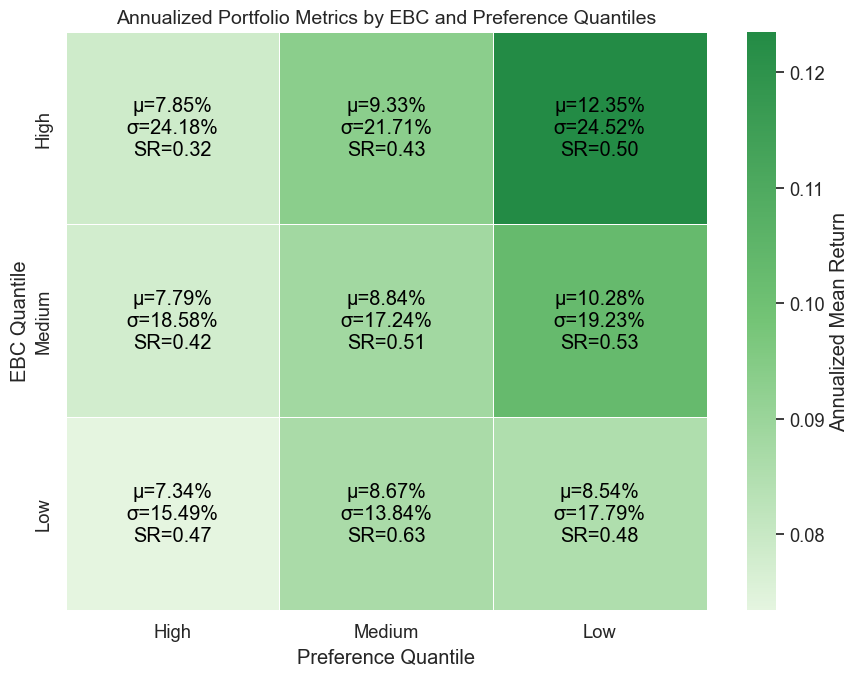

In [276]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Label mappings
ebc_labels = {1: "High", 2: "Medium", 3: "Low"}
pref_labels = {1: "High", 2: "Medium", 3: "Low"}

# Initialize nested dicts for results
heatmap_data = {}
mean_data = {}

for q1 in range(1, n_q1 + 1):
    ebc_label = ebc_labels[q1]
    heatmap_data[ebc_label] = {}
    mean_data[ebc_label] = {}
    for q2 in range(1, n_q2 + 1):
        pref_label = pref_labels[q2]
        col_name = f"Q{q1}_Q{q2}"
        returns = all_portfolio_returns[col_name].dropna()

        if len(returns) < 3:
            mean_annual = np.nan
            vol_annual = np.nan
            sharpe_annual = np.nan
        else:
            mean_monthly = returns.mean()
            vol_monthly = returns.std()

            mean_annual = mean_monthly * 12
            vol_annual = vol_monthly * np.sqrt(12)
            sharpe_annual = (mean_monthly / vol_monthly) * np.sqrt(12) if vol_monthly != 0 else np.nan

        mean_data[ebc_label][pref_label] = mean_annual
        heatmap_data[ebc_label][pref_label] = (
            f"μ={mean_annual:.2%}\n"
            f"σ={vol_annual:.2%}\n"
            f"SR={sharpe_annual:.2f}"
        )

# Convert to DataFrames
heatmap_df = pd.DataFrame(heatmap_data).T
mean_df = pd.DataFrame(mean_data).T  # numeric values for coloring

# Custom soft-green colormap
colors = ["#e5f5e0", "#74c476", "#238b45"]  # light → medium → deeper green
green_cmap = LinearSegmentedColormap.from_list("custom_green", colors)

# Plot
plt.figure(figsize=(9, 7))
sns.heatmap(
    mean_df,
    cmap=green_cmap,
    annot=heatmap_df,
    fmt="",
    linewidths=0.7,
    annot_kws={"color": "black"},
    cbar_kws={'label': 'Annualized Mean Return'},
)

plt.title("Annualized Portfolio Metrics by EBC and Preference Quantiles", fontsize=14)
plt.xlabel("Preference Quantile")
plt.ylabel("EBC Quantile")
plt.tight_layout()
plt.show()


1_1
0.20859714010508829
0.21536547020914498
aaaaa
1_2
0.16631490828930062
0.2094583169576463
aaaaa
1_3
0.16952277434794288
0.2351182963844174
aaaaa
2_1
0.20536676512021312
0.18950424130629606
aaaaa
2_2
0.13925006773989412
0.16324347615115706
aaaaa
2_3
0.1244262375135657
0.17668253069035894
aaaaa
3_1
0.17240711727161273
0.16591834949353182
aaaaa
3_2
0.1011885218287859
0.12313356899321505
aaaaa
3_3
0.10882476958946743
0.12559502477575718
aaaaa
Market
0.18782242250102013
0.15338943270086416


,Q1,Q2,Q3
Q1,0.968573,0.794024,0.721011
Q2,1.083705,0.853021,0.704236
Q3,1.039108,0.821779,0.866474


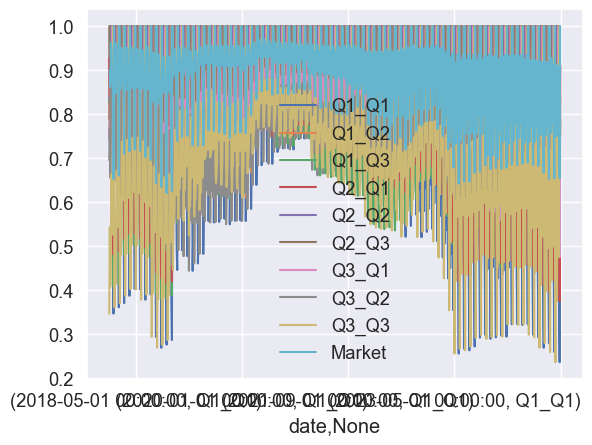

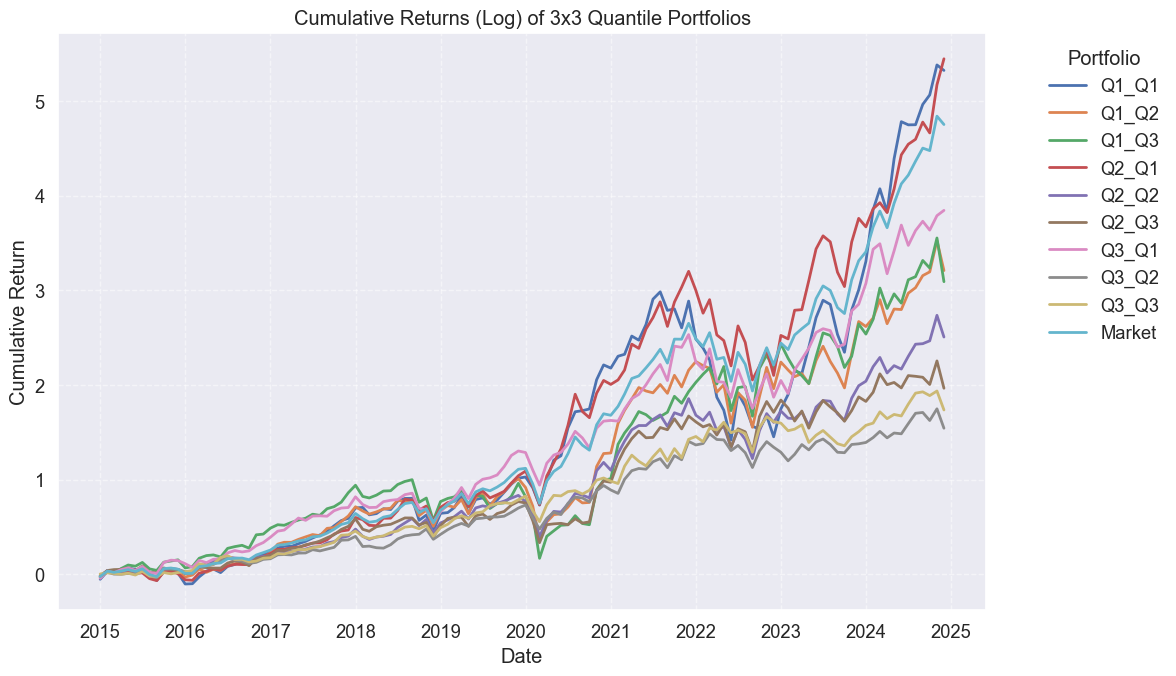

In [302]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#this is the important one


sp_500 = pd.read_csv('sp500_returns_with_tickers.csv', index_col=0)
sp_500.index = pd.to_datetime(sp_500.index).to_period('M').start_time  # monthly timestamp
sp_caps = pd.read_csv('sp500_market_caps.csv', index_col=0)
sp_caps.index = pd.to_datetime(sp_caps.index).to_period('M').start_time  # monthly timestamp

quantile_map_df = quantile_map_df.copy()
quantile_map_df['month'] = quantile_map_df.index.get_level_values('date').to_period('M')


n_q1, n_q2 = 3, 3  # 3x3 grid
months = quantile_map_df.index.get_level_values('date').to_period('M').sort_values().unique()

# Container for all portfolio returns
all_portfolio_returns = pd.DataFrame(index=months.to_timestamp())

#iterate over quantile portfolios and calculate log returns
for q1 in range(1, n_q1 + 1):
    for q2 in range(1, n_q2 + 1):
        portfolio_returns = []
        for month in months:
            # select rows for this month & quantile cell
            mask = (
                (quantile_map_df['month'] == month) &
                (quantile_map_df.index.get_level_values('q1') == q1) &
                (quantile_map_df.index.get_level_values('q2') == q2)
            )
            subset = quantile_map_df.loc[mask, 'stocks']

            if subset.empty:
                portfolio_returns.append(np.nan)
                continue

            # flatten and remove duplicates
            tickers = sorted(set([stk for sublist in subset for stk in sublist]))
            if len(tickers) == 0:
                portfolio_returns.append(np.nan)
                continue

            # get monthly return row for those tickers
            ret_row = sp_500.loc[sp_500.index.to_period('M') == month, tickers]

            # get matching market caps for the same month
            caps_row = sp_caps.loc[sp_caps.index.to_period('M') == month, tickers]

            # ensure alignment and handle missing caps
            valid_tickers = [t for t in tickers if t in caps_row.columns and not np.isnan(caps_row[t].values[0])]
            if len(valid_tickers) == 0:
                portfolio_returns.append(np.nan)
                continue

            ret_row = ret_row[valid_tickers]
            caps_row = caps_row[valid_tickers]

            # compute weights normalized to 1
            weights = caps_row.values[0]
            weights = weights / np.nansum(weights)

            # cap-weighted return
            ret = np.nansum(ret_row.values[0] * weights)
            portfolio_returns.append(ret)

        # add to DataFrame
        col_name = f"Q{q1}_Q{q2}"
        all_portfolio_returns[col_name] = portfolio_returns

cap_weighted = pd.read_csv('sp500_cap_weighted_returns.csv', index_col=0)
cap_weighted.index = pd.to_datetime(cap_weighted.index).to_period('M').to_timestamp()
cap_weighted.columns = ["Market"]

# Also make sure all_portfolio_returns has a DatetimeIndex
all_portfolio_returns.index = pd.to_datetime(all_portfolio_returns.index).to_period('M').to_timestamp()

# Find the common index
common_index = all_portfolio_returns.index.intersection(cap_weighted.index)

# Align both to the common index
cap_weighted = cap_weighted.loc[common_index]
all_portfolio_returns = all_portfolio_returns.loc[common_index]

#this is to look at shorter periods of time
start_date = '2015-01-01'

all_portfolio_returns = all_portfolio_returns.subtract(rf, axis=0)
all_portfolio_returns["Market"] = cap_weighted["Market"]
all_portfolio_returns = all_portfolio_returns.loc[all_portfolio_returns.index >= start_date]

(all_portfolio_returns.rolling(window=36).corr()).plot()


# log(1 + r) for each month
log_returns = np.log1p(all_portfolio_returns)
# cumulative log return
cumulative_log_returns = log_returns.cumsum()
# optionally convert back to normal cumulative return
cumulative_returns = np.expm1(cumulative_log_returns)

sharpe_matrix = pd.DataFrame(index=[f"Q{i}" for i in range(1, n_q1 + 1)],
                             columns=[f"Q{j}" for j in range(1, n_q2 + 1)])

vol_grid = []
for q1 in range(1, n_q1 + 1):
    for q2 in range(1, n_q2 + 1):
        col_name = f"Q{q1}_Q{q2}"
        returns = all_portfolio_returns[col_name].dropna()
        print(f'{q1}_{q2}')
        if len(returns) < 3:
            sharpe = np.nan
        else:
            mean_ret = returns.mean()   # annualized mean
            print(mean_ret * 12)
            vol = returns.std()   # annualized vol
            vol_grid.append(vol * np.sqrt(12))

            print(vol * np.sqrt(12))
            print("aaaaa")
            sharpe = mean_ret / vol if vol != 0 else np.nan
            sharpe *= np.sqrt(12)
        
        sharpe_matrix.loc[f"Q{q1}", f"Q{q2}"] = sharpe

print("Market")
print(all_portfolio_returns["Market"].mean() * 12)
print(all_portfolio_returns["Market"].std() * np.sqrt(12))

# Convert to numeric for plotting or exporting
sharpe_matrix = sharpe_matrix.astype(float)

display(sharpe_matrix)

#plot
plt.figure(figsize=(12,7))
for col in cumulative_returns.columns:
    # if col == "Market":
    plt.plot(cumulative_returns.index, cumulative_returns[col], label=col, linewidth=2)
    # elif col == "Q1_Q3":
    # plt.plot(cumulative_returns.index, cumulative_returns[col], label=col, linewidth=2)

plt.title("Cumulative Returns (Log) of 3x3 Quantile Portfolios")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend(title='Portfolio', bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


        date stock  q1  q2
0 1983-09-01  AAPL   1   1
1 1983-09-01  AAPL   1   1
2 1983-09-01  AAPL   1   1
3 1983-10-01  AAPL   1   1
4 1983-10-01  AAPL   1   1
5 1983-10-01  AAPL   1   1
6 1983-11-01  AAPL   1   1
7 1983-11-01  AAPL   1   1
8 1983-11-01  AAPL   1   1
9 1983-12-01  AAPL   1   1


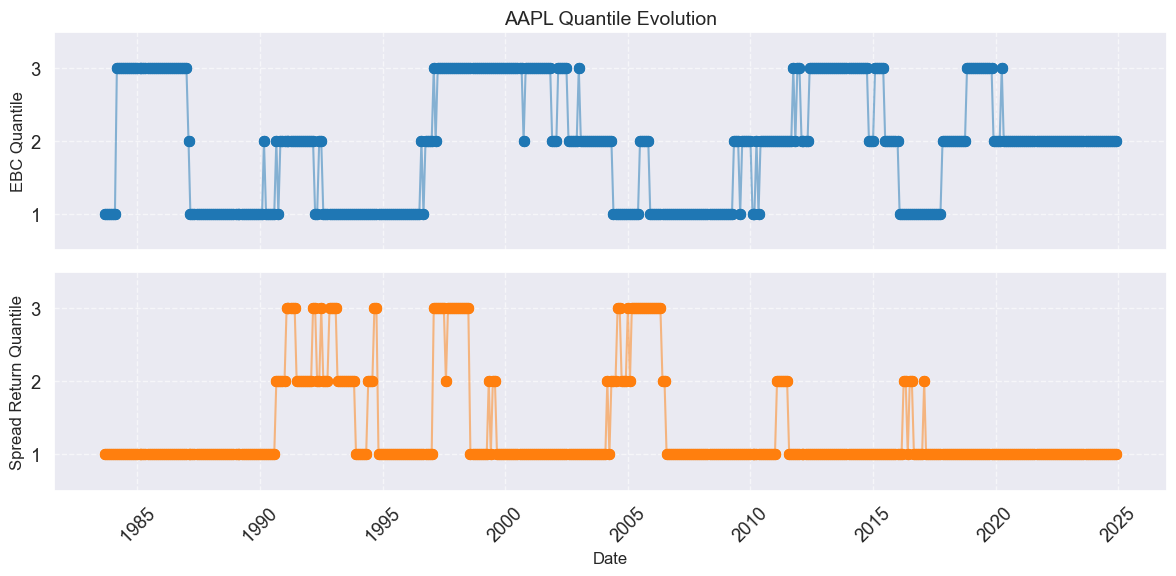

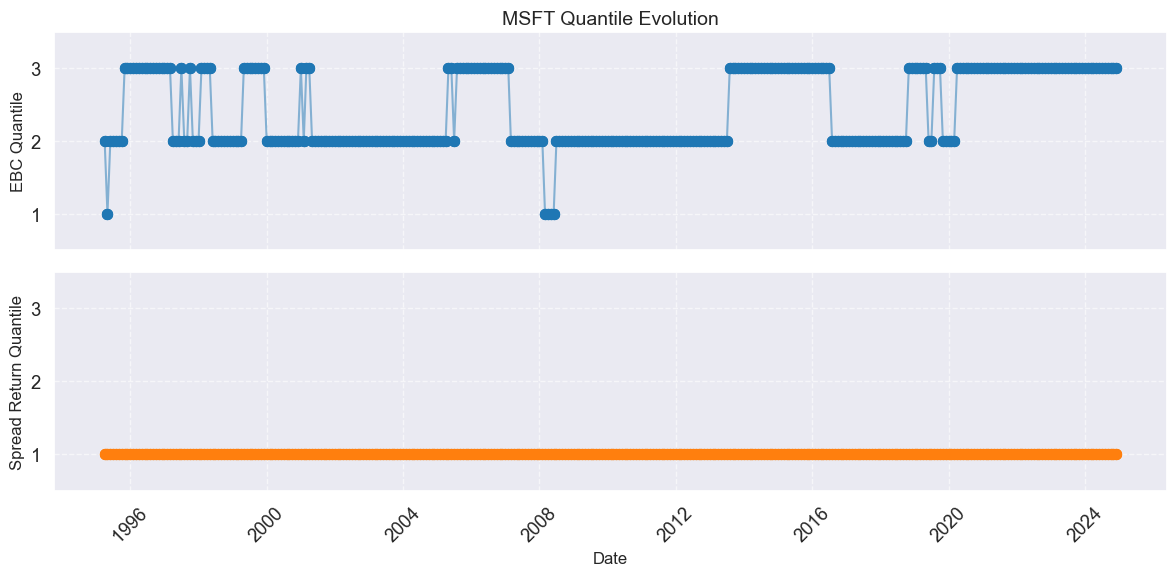

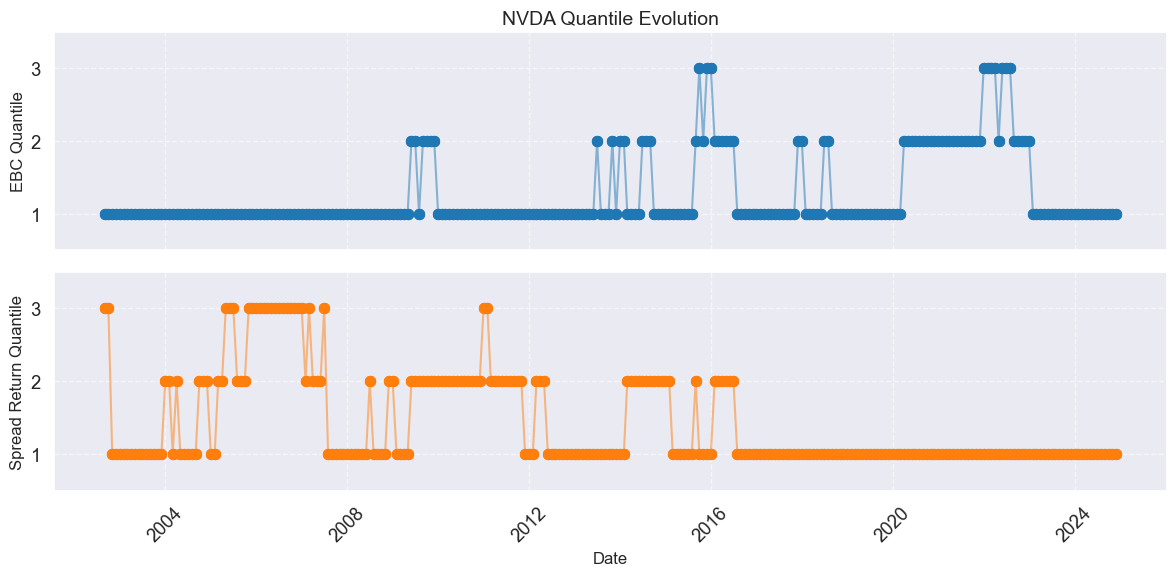

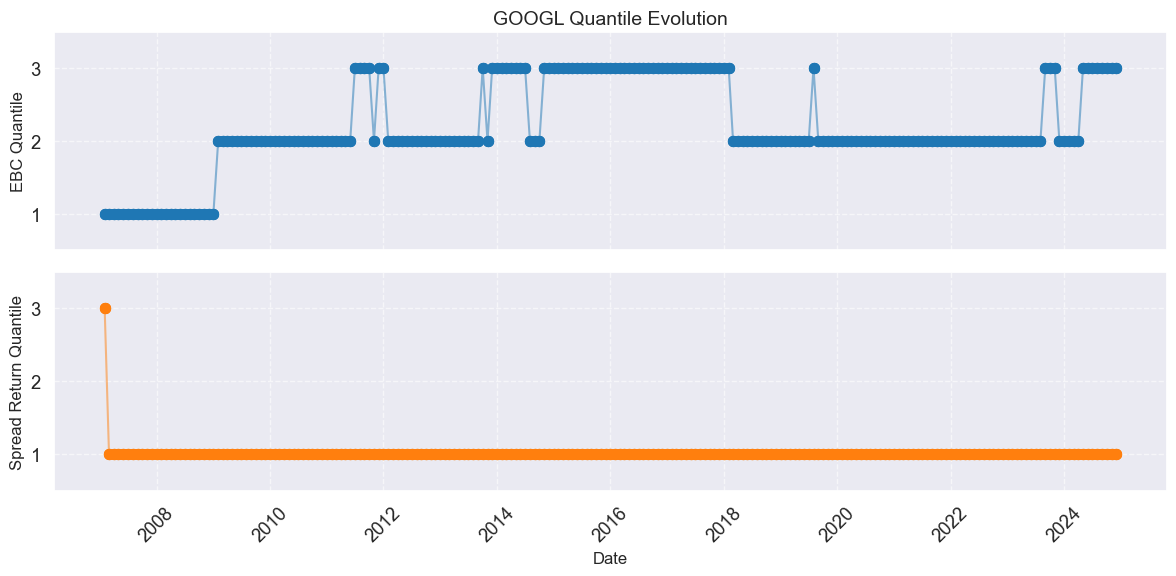

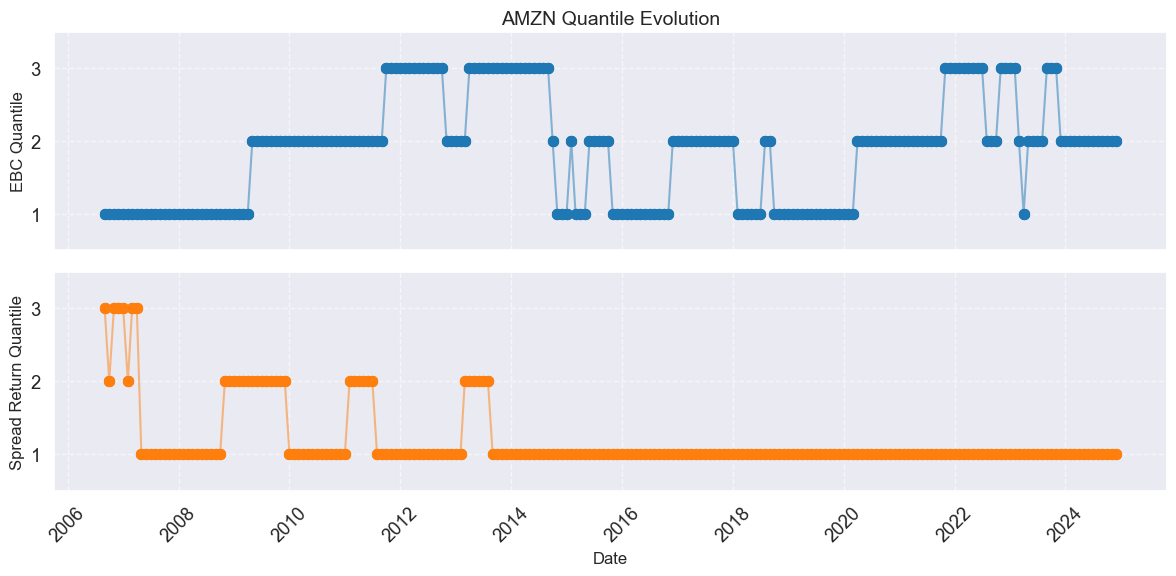

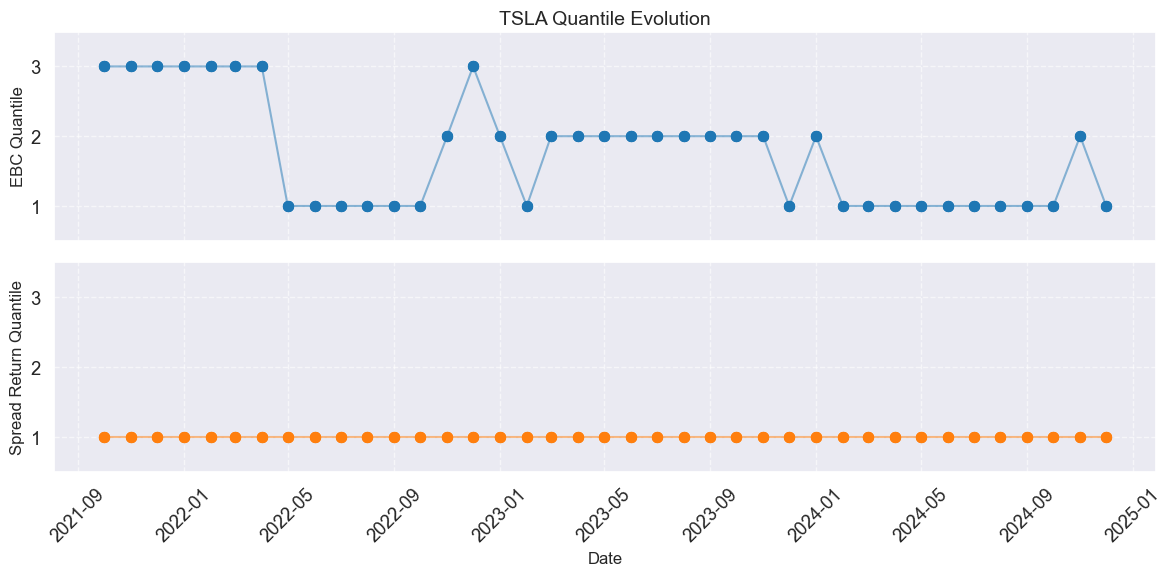

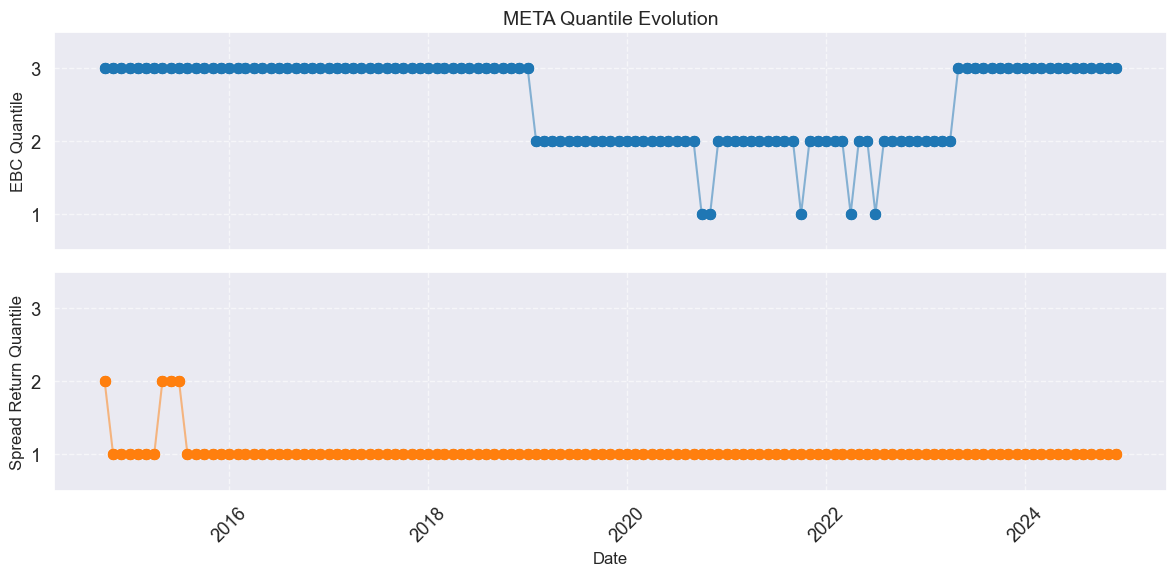

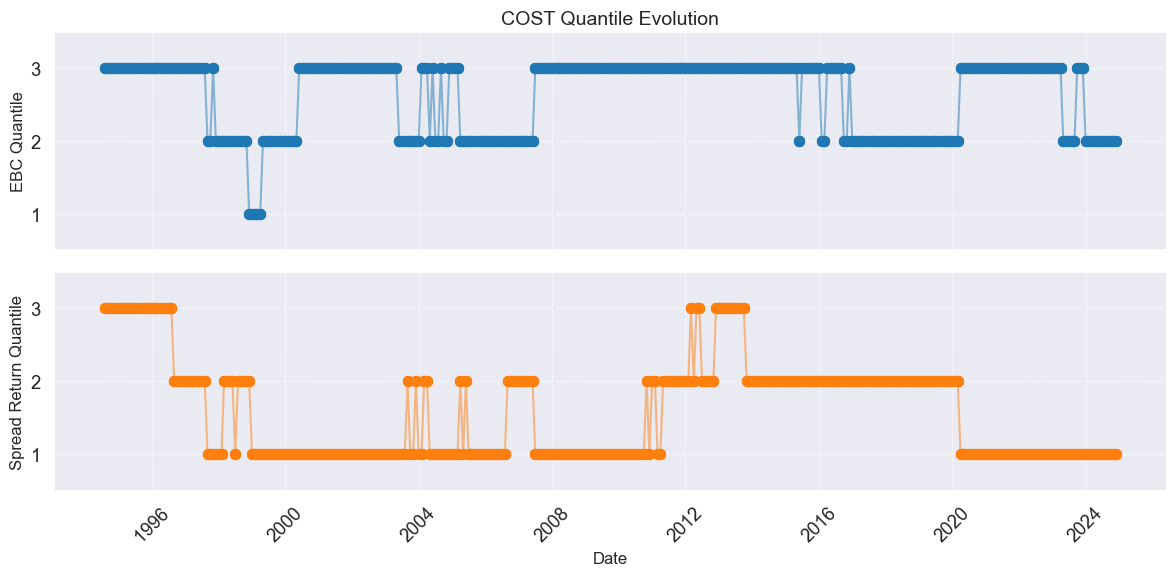

In [242]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- Inputs ----
tracked_stocks = ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'AMZN', 'TSLA', 'META', "COST"]   # change to any list of tickers you want to track
start_date = pd.Timestamp('1970-01-01')     # or '2000-01-01' etc.

# Ensure date index is datetime
quantile_map_df = quantile_map_df.copy()
quantile_map_df = quantile_map_df.reset_index()
quantile_map_df['date'] = pd.to_datetime(quantile_map_df['date'])
quantile_map_df = quantile_map_df.set_index(['date', 'q1', 'q2']).sort_index()

# Filter to start_date and available range
quantile_map_df = quantile_map_df.loc[quantile_map_df.index.get_level_values('date') >= start_date]

# Collect results
records = []

for (date, q1, q2), row in quantile_map_df.iterrows():
    stocks_in_cell = row['stocks']
    if not isinstance(stocks_in_cell, list):
        continue
    for stk in tracked_stocks:
        if stk in stocks_in_cell:
            records.append({'date': date, 'stock': stk, 'q1': q1, 'q2': q2})

# Convert to DataFrame
tracking_df = pd.DataFrame(records)
tracking_df = tracking_df.sort_values(['stock', 'date'])

print(tracking_df.head(10))

# ---- Plot each stock's quantile path ----
for stk in tracked_stocks:
    stk_df = tracking_df[tracking_df['stock'] == stk]
    if stk_df.empty:
        print(f"No data for {stk}")
        continue

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    # Plot q1
    axes[0].scatter(stk_df['date'], stk_df['q1'], color='tab:blue', s=50)
    axes[0].plot(stk_df['date'], stk_df['q1'], color='tab:blue', alpha=0.5)
    axes[0].set_ylabel(f'{f1_name} Quantile', fontsize=12)
    axes[0].set_title(f'{stk} Quantile Evolution', fontsize=14)
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].set_ylim(0.5, max(tracking_df['q1'].max(), tracking_df['q2'].max()) + 0.5)

    # Plot q2
    axes[1].scatter(stk_df['date'], stk_df['q2'], color='tab:orange', s=50)
    axes[1].plot(stk_df['date'], stk_df['q2'], color='tab:orange', alpha=0.5)
    axes[1].set_ylabel(f'{f2_name} Quantile', fontsize=12)
    axes[1].set_xlabel('Date', fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.6)
    axes[1].set_ylim(0.5, max(tracking_df['q1'].max(), tracking_df['q2'].max()) + 0.5)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

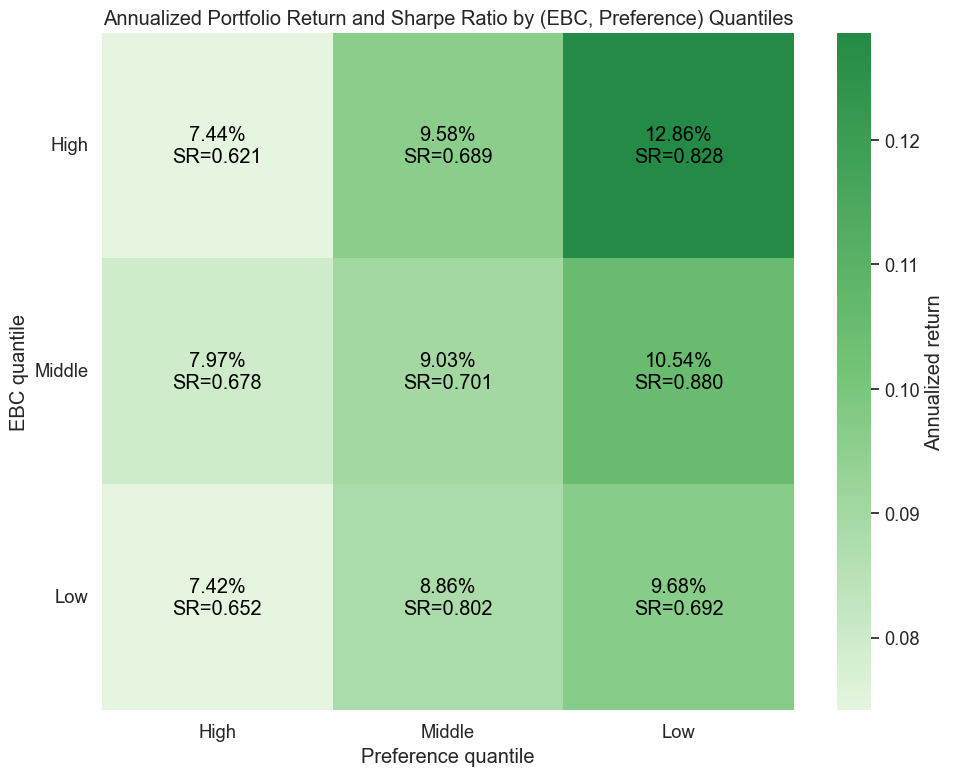

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Ensure consistent index/column labels between the two grids
mean_grid_annual.index = [f"Q{i}" for i in range(1, mean_grid_annual.shape[0] + 1)]
mean_grid_annual.columns = [f"Q{j}" for j in range(1, mean_grid_annual.shape[1] + 1)]

sharpe_matrix.index = [f"Q{i}" for i in range(1, sharpe_matrix.shape[0] + 1)]
sharpe_matrix.columns = [f"Q{j}" for j in range(1, sharpe_matrix.shape[1] + 1)]

# Create annotation text combining returns and Sharpe ratios
annot_text = pd.DataFrame(index=mean_grid_annual.index, columns=mean_grid_annual.columns)

for i in mean_grid_annual.index:
    for j in mean_grid_annual.columns:
        ret = mean_grid_annual.loc[i, j]
        vol = vol_grid.loc[i, j]
        sharpe = sharpe_matrix.loc[i, j]
        if pd.notna(ret) and pd.notna(sharpe):
            annot_text.loc[i, j] = f"{ret:.2%}\nSR={sharpe:.3f}"
        elif pd.notna(ret):
            annot_text.loc[i, j] = f"{ret:.2%}"
        else:
            annot_text.loc[i, j] = ""

# Plot
plt.figure(figsize=(10, 8))
#colors = ["#d9f0d3", "#74c476", "#006d2c"]  # light mint → medium green → dark forest
colors = ["#e5f5e0", "#74c476", "#238b45"]


custom_cmap = LinearSegmentedColormap.from_list("poster_green_gradient", colors)
sns.heatmap(
    mean_grid_annual,
    annot=annot_text,
    fmt="",
    cmap=custom_cmap,
    cbar_kws={'label': 'Annualized return'},
    annot_kws={"color": "black"}
)
plt.title("Annualized Portfolio Return and Sharpe Ratio by (EBC, Preference) Quantiles")
plt.xlabel("Preference quantile")
plt.ylabel("EBC quantile")
plt.xticks(ticks=np.arange(3) + 0.5, labels=['High', 'Middle', 'Low'])
plt.yticks(ticks=np.arange(3) + 0.5, labels=['High', 'Middle', 'Low'], rotation=0)
plt.tight_layout()
plt.show()



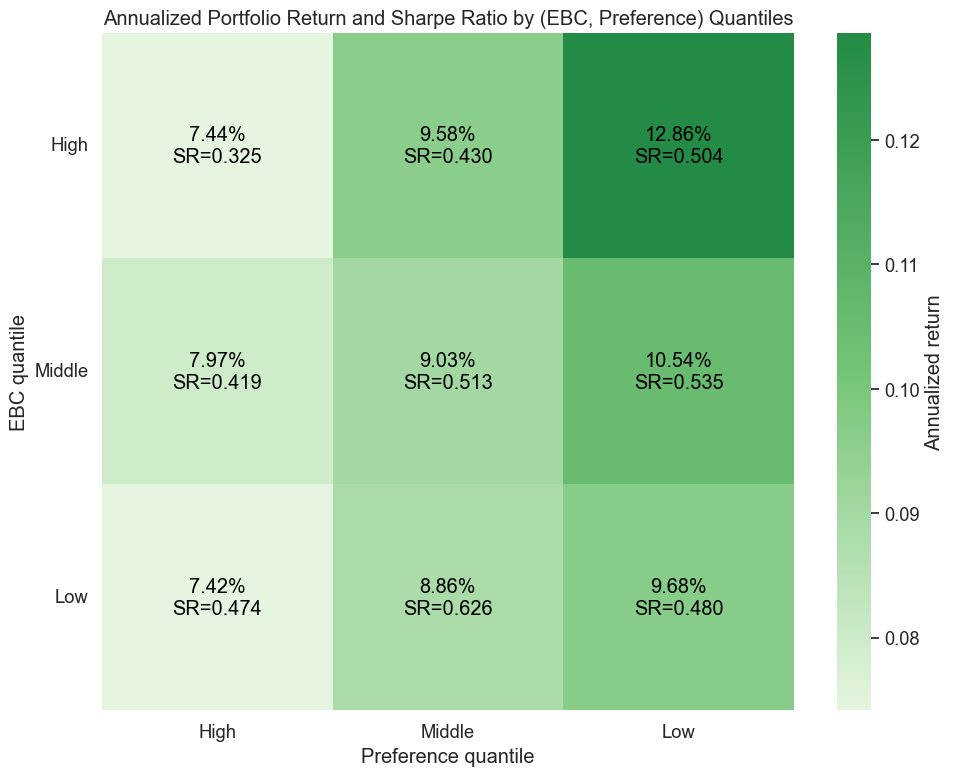

In [266]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Ensure consistent index/column labels between the two grids
mean_grid_annual.index = [f"Q{i}" for i in range(1, mean_grid_annual.shape[0] + 1)]
mean_grid_annual.columns = [f"Q{j}" for j in range(1, mean_grid_annual.shape[1] + 1)]

sharpe_matrix_EW.index = [f"Q{i}" for i in range(1, sharpe_matrix_EW.shape[0] + 1)]
sharpe_matrix_EW.columns = [f"Q{j}" for j in range(1, sharpe_matrix_EW.shape[1] + 1)]

# Create annotation text combining returns and Sharpe ratios
annot_text = pd.DataFrame(index=mean_grid_annual.index, columns=mean_grid_annual.columns)

for i in mean_grid_annual.index:
    for j in mean_grid_annual.columns:
        ret = mean_grid_annual.loc[i, j]
        sharpe = sharpe_matrix_EW.loc[i, j]
        if pd.notna(ret) and pd.notna(sharpe):
            annot_text.loc[i, j] = f"{ret:.2%}\nSR={sharpe:.3f}"
        elif pd.notna(ret):
            annot_text.loc[i, j] = f"{ret:.2%}"
        else:
            annot_text.loc[i, j] = ""

# Plot
plt.figure(figsize=(10, 8))
#colors = ["#d9f0d3", "#74c476", "#006d2c"]  # light mint → medium green → dark forest
colors = ["#e5f5e0", "#74c476", "#238b45"]


custom_cmap = LinearSegmentedColormap.from_list("poster_green_gradient", colors)
sns.heatmap(
    mean_grid_annual,
    annot=annot_text,
    fmt="",
    cmap=custom_cmap,
    cbar_kws={'label': 'Annualized return'},
    annot_kws={"color": "black"}
)
plt.title("Annualized Portfolio Return and Sharpe Ratio by (EBC, Preference) Quantiles")
plt.xlabel("Preference quantile")
plt.ylabel("EBC quantile")
plt.xticks(ticks=np.arange(3) + 0.5, labels=['High', 'Middle', 'Low'])
plt.yticks(ticks=np.arange(3) + 0.5, labels=['High', 'Middle', 'Low'], rotation=0)
plt.tight_layout()
plt.show()

